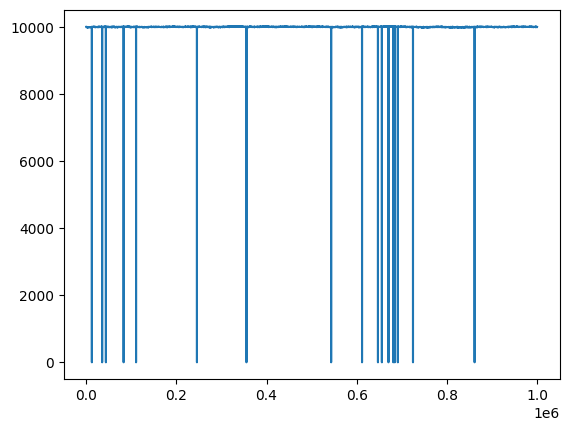

In [538]:
import pandas as pd
import matplotlib.pyplot as plt
import statistics

prices_df = pd.read_csv("../datasets/round1/prices_round_1_day_-1.csv", sep=';')

pepper_prices_df = prices_df[prices_df["product"] == "INTARIAN_PEPPER_ROOT" ]
osmium_prices_df = prices_df[prices_df["product"] == "ASH_COATED_OSMIUM" ]
# tomatoes_df = df[["timestamp", "mid_price"]]
pepper_prices_df

#tomatopricesvolumeover5 = tomatoes_prices_df[tomatoes_prices_df[""] >= 5]

#plt.plot(pepper_prices_df['timestamp'], pepper_prices_df['mid_price'])
plt.plot(osmium_prices_df['timestamp'], osmium_prices_df['mid_price'])

Counts: day-2 pepper 344 osmium 429 tomatoes 0
Counts: day-1 pepper 335 osmium 425 tomatoes 0


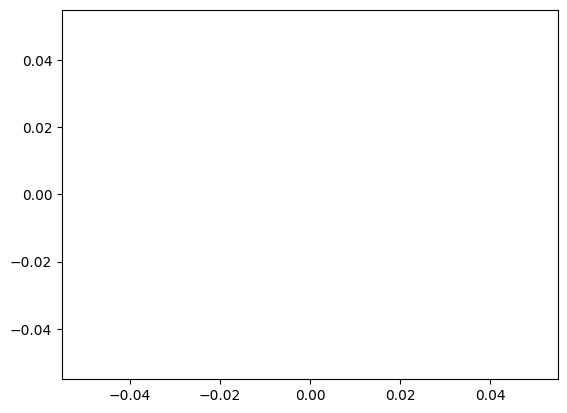

In [539]:
# Load round1 trades (day -2 and day -1)
day_02_trades_df = pd.read_csv("../datasets/round1/trades_round_1_day_-2.csv", sep=';')
day_01_trades_df = pd.read_csv("../datasets/round1/trades_round_1_day_-1.csv", sep=';')

# Filter trades for round1 products used in the notebook
day_02_pepper_trades = day_02_trades_df[day_02_trades_df["symbol"] == "INTARIAN_PEPPER_ROOT"].sort_values('timestamp')
day_01_pepper_trades = day_01_trades_df[day_01_trades_df["symbol"] == "INTARIAN_PEPPER_ROOT"].sort_values('timestamp')

day_02_osmium_trades = day_02_trades_df[day_02_trades_df["symbol"] == "ASH_COATED_OSMIUM"].sort_values('timestamp')
day_01_osmium_trades = day_01_trades_df[day_01_trades_df["symbol"] == "ASH_COATED_OSMIUM"].sort_values('timestamp')

# Keep TOMATOES too for the existing plots/analysis
day_02_tomatoes_trades_df = day_02_trades_df[day_02_trades_df["symbol"] == "TOMATOES"].sort_values('timestamp')
day_01_tomatoes_trades_df = day_01_trades_df[day_01_trades_df["symbol"] == "TOMATOES"].sort_values('timestamp')

print('Counts: day-2 pepper', len(day_02_pepper_trades), 'osmium', len(day_02_osmium_trades), 'tomatoes', len(day_02_tomatoes_trades_df))
print('Counts: day-1 pepper', len(day_01_pepper_trades), 'osmium', len(day_01_osmium_trades), 'tomatoes', len(day_01_tomatoes_trades_df))

quantity5trades = day_02_tomatoes_trades_df[day_02_tomatoes_trades_df["quantity"] >= 5]

plt.plot(day_02_tomatoes_trades_df['timestamp'], day_02_tomatoes_trades_df['price'])
#plt.plot(day_02_tomatoes_trades_df['timestamp'], day_02_tomatoes_trades_df['quantity'])

plt.plot(quantity5trades['timestamp'], quantity5trades['price'], 'ro')

n=10000 slope=1.008554e-03 intercept=10976.253212 r2=0.275548 p=0.0 std_err=1.6354932776430392e-05


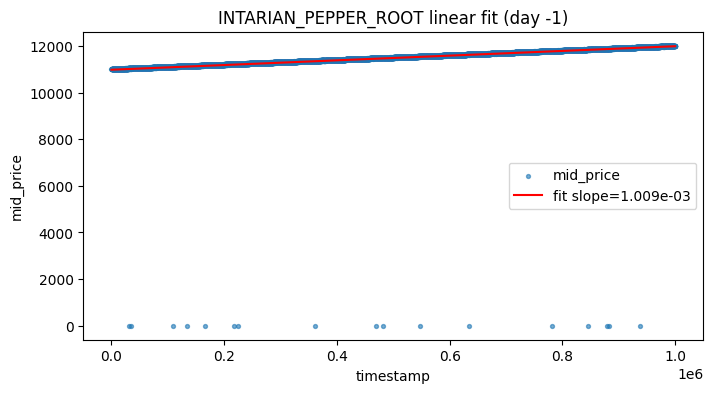

In [540]:
# Linear regression of INTARIAN_PEPPER_ROOT mid_price vs timestamp (day -1)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

path = '../datasets/round1/prices_round_1_day_-1.csv'
df = pd.read_csv(path, sep=';')
pep = df[df['product'] == 'INTARIAN_PEPPER_ROOT'].sort_values('timestamp')
ts = pep['timestamp'].astype(float).to_numpy()
prices = pep['mid_price'].astype(float).to_numpy()
# use raw timestamp as x-axis (no conversion to seconds)
slope, intercept, r_value, p_value, std_err = stats.linregress(ts, prices)
print(f'n={len(prices)} slope={slope:.6e} intercept={intercept:.6f} r2={r_value**2:.6f} p={p_value} std_err={std_err}')
plt.figure(figsize=(8,4))
plt.scatter(ts, prices, s=8, alpha=0.6, label='mid_price')
xs = np.linspace(ts.min(), ts.max(), 200)
ys = intercept + slope * xs
plt.plot(xs, ys, 'r-', label=f'fit slope={slope:.3e}')
plt.xlabel('timestamp')
plt.ylabel('mid_price')
plt.title('INTARIAN_PEPPER_ROOT linear fit (day -1)')
plt.legend()
plt.show()

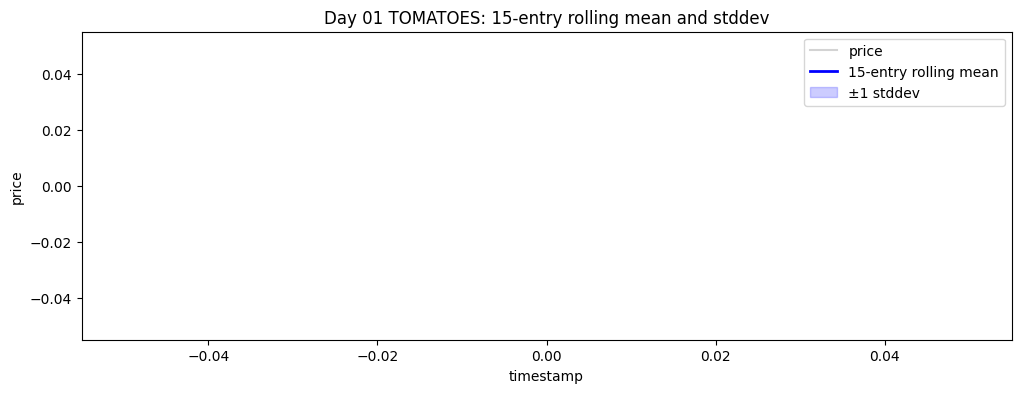

In [541]:
# 15-entry rolling mean and stddev for day 01 TOMATOES trades
df = day_01_tomatoes_trades_df.sort_values('timestamp')
roll = df['price'].rolling(window=15, min_periods=15)
rolling_mean = roll.mean()
rolling_std = roll.std()

plt.figure(figsize=(12,4))
plt.plot(df['timestamp'], df['price'], color='lightgray', label='price')
plt.plot(df['timestamp'], rolling_mean, color='blue', linewidth=2, label='15-entry rolling mean')
plt.fill_between(df['timestamp'], rolling_mean - rolling_std, rolling_mean + rolling_std, color='blue', alpha=0.2, label='±1 stddev')
plt.xlabel('timestamp')
plt.ylabel('price')
plt.legend()
plt.title('Day 01 TOMATOES: 15-entry rolling mean and stddev')
plt.show()

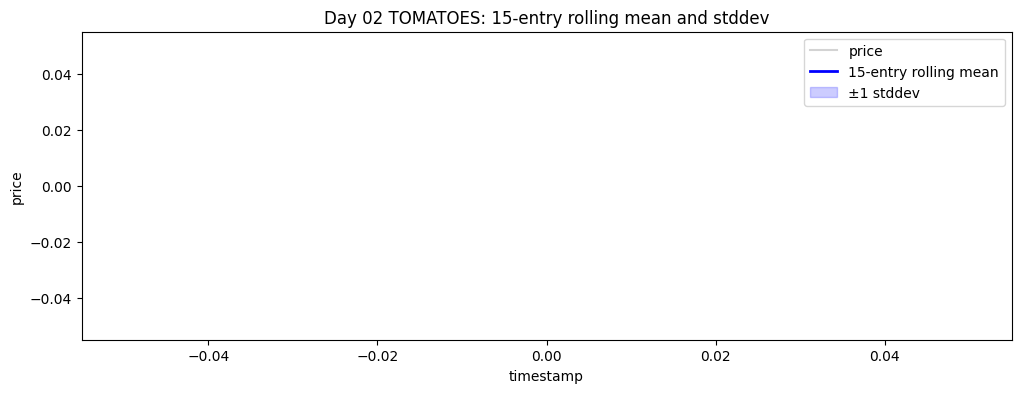

In [542]:
# 15-entry rolling mean and stddev for day 02 TOMATOES trades
df = day_02_tomatoes_trades_df.sort_values('timestamp')
roll = df['price'].rolling(window=500, min_periods=500)
rolling_mean = roll.mean()
rolling_std = roll.std()

plt.figure(figsize=(12,4))
plt.plot(df['timestamp'], df['price'], color='lightgray', label='price')
plt.plot(df['timestamp'], rolling_mean, color='blue', linewidth=2, label='15-entry rolling mean')
plt.fill_between(df['timestamp'], rolling_mean - rolling_std, rolling_mean + rolling_std, color='blue', alpha=0.2, label='±1 stddev')
plt.xlabel('timestamp')
plt.ylabel('price')
plt.legend()
plt.title('Day 02 TOMATOES: 15-entry rolling mean and stddev')
plt.show()

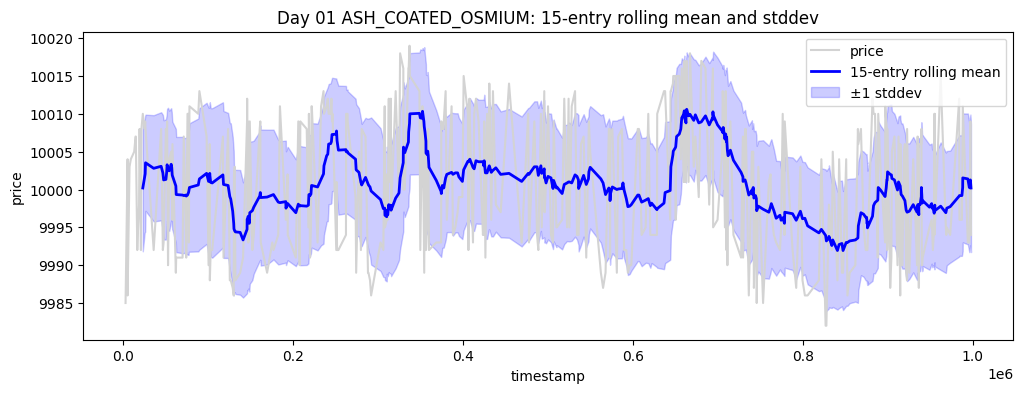

In [543]:
# 15-entry rolling mean and stddev for day 01 ASH_COATED_OSMIUM trades
df = day_01_osmium_trades.sort_values('timestamp')
roll = df['price'].rolling(window=15, min_periods=15)
rolling_mean = roll.mean()
rolling_std = roll.std()

plt.figure(figsize=(12,4))
plt.plot(df['timestamp'], df['price'], color='lightgray', label='price')
plt.plot(df['timestamp'], rolling_mean, color='blue', linewidth=2, label='15-entry rolling mean')
plt.fill_between(df['timestamp'], rolling_mean - rolling_std, rolling_mean + rolling_std, color='blue', alpha=0.2, label='±1 stddev')
plt.xlabel('timestamp')
plt.ylabel('price')
plt.legend()
plt.title('Day 01 ASH_COATED_OSMIUM: 15-entry rolling mean and stddev')
plt.show()

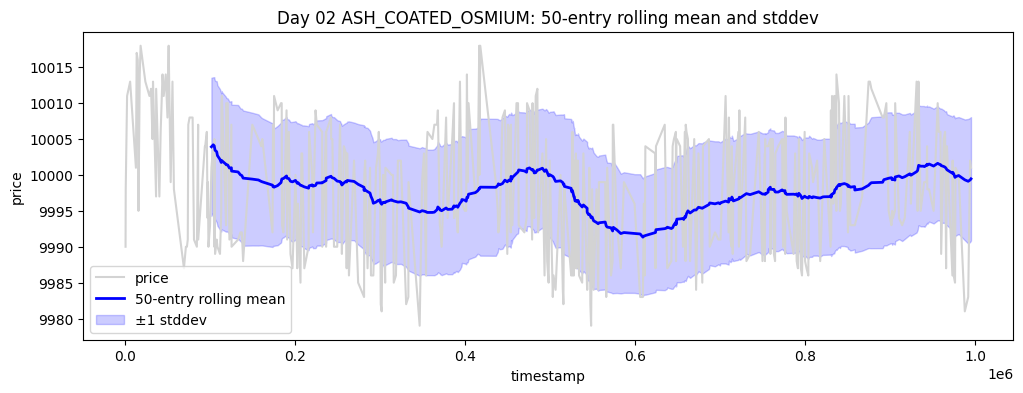

In [544]:
# 50-entry rolling mean and stddev for day 02 ASH_COATED_OSMIUM trades
df = day_02_osmium_trades.sort_values('timestamp')
roll = df['price'].rolling(window=50, min_periods=50)
rolling_mean = roll.mean()
rolling_std = roll.std()

plt.figure(figsize=(12,4))
plt.plot(df['timestamp'], df['price'], color='lightgray', label='price')
plt.plot(df['timestamp'], rolling_mean, color='blue', linewidth=2, label='50-entry rolling mean')
plt.fill_between(df['timestamp'], rolling_mean - rolling_std, rolling_mean + rolling_std, color='blue', alpha=0.2, label='±1 stddev')
plt.xlabel('timestamp')
plt.ylabel('price')
plt.legend()
plt.title('Day 02 ASH_COATED_OSMIUM: 50-entry rolling mean and stddev')
plt.show()

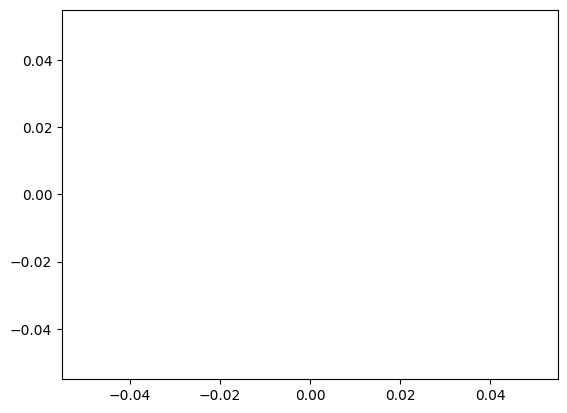

In [545]:
day_01_emerald_trades_df = day_01_trades_df[day_01_trades_df["symbol"] == "EMERALDS" ]



plt.plot(day_01_emerald_trades_df['timestamp'], day_01_emerald_trades_df['price'])


Hurst: day -1: 0.1521, day -2: 0.1518, combined: 0.2317


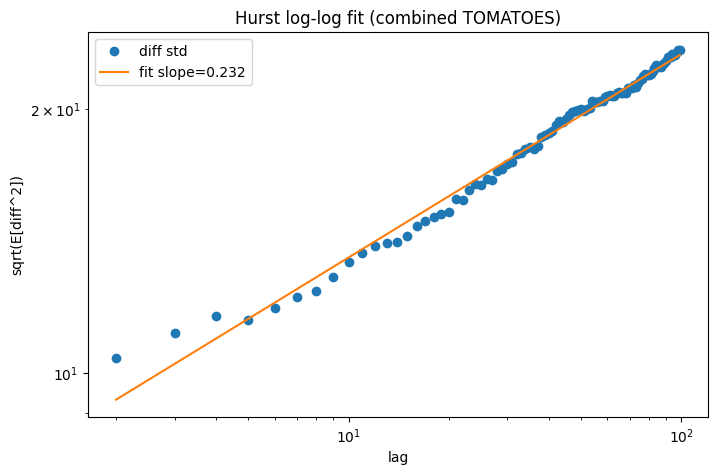

In [546]:
# Hurst exponent test and log-log plot for TOMATOES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def hurst_exponent(prices, maxlag=None):
    ts = np.asarray(prices, dtype=float)
    N = len(ts)
    if N < 10:
        return np.nan, None, None
    if maxlag is None:
        maxlag = min(100, max(10, N // 2))
    lags = np.arange(2, maxlag)
    tau = []
    for lag in lags:
        diff = ts[lag:] - ts[:-lag]
        tau.append(np.sqrt(np.mean(diff**2)))
    # linear fit on log-log
    slope, intercept, r_value, p_value, std_err = stats.linregress(np.log(lags), np.log(tau))
    H = slope
    return float(H), (lags, tau), (slope, intercept)

# load trades (they are already loaded in previous cells; but re-read to be safe)
d1 = pd.read_csv('../datasets/tutorial/trades_round_0_day_-1.csv', sep=';')
d2 = pd.read_csv('../datasets/tutorial/trades_round_0_day_-2.csv', sep=';')
t1 = d1[d1['symbol'] == 'TOMATOES'].sort_values('timestamp')
t2 = d2[d2['symbol'] == 'TOMATOES'].sort_values('timestamp')
p1 = t1['price'].to_numpy()
p2 = t2['price'].to_numpy()
combined = np.concatenate([p1, p2]) if (len(p1) and len(p2)) else (p1 if len(p1) else p2)

# compute Hurst for day -1, day -2, and combined
H1, data1, fit1 = hurst_exponent(p1)
H2, data2, fit2 = hurst_exponent(p2)
Hc, datac, fitc = hurst_exponent(combined)
print('Hurst: day -1: {:.4f}, day -2: {:.4f}, combined: {:.4f}'.format(H1, H2, Hc))

# plot log-log with linear fit for combined (if available)
if datac is not None:
    lags, tau = datac
    slope, intercept = fitc
    plt.figure(figsize=(8,5))
    plt.loglog(lags, tau, 'o', label='diff std')
    plt.loglog(lags, np.exp(intercept) * lags**slope, '-', label=f'fit slope={slope:.3f}')
    plt.xlabel('lag')
    plt.ylabel('sqrt(E[diff^2])')
    plt.title('Hurst log-log fit (combined TOMATOES)')
    plt.legend()
    plt.show()

# save price series and Hurst results to CSV
out_df = pd.DataFrame({'price': combined})
out_df.to_csv('tomato_prices_combined.csv', index=False)
with open('tomato_hurst_results.txt', 'w') as f:
    f.write(f"day -1: n={len(p1)} H={H1}\n")
    f.write(f"day -2: n={len(p2)} H={H2}\n")
    f.write(f"combined: n={len(combined)} H={Hc}\n")

In [547]:
# Combine all three round 1 days for ASH_COATED_OSMIUM and compute the average mid_price
day_02_prices_df = pd.read_csv("../datasets/round1/prices_round_1_day_-2.csv", sep=";")
day_01_prices_df = pd.read_csv("../datasets/round1/prices_round_1_day_-1.csv", sep=";")
day_0_prices_df = pd.read_csv("../datasets/round1/prices_round_1_day_0.csv", sep=";")

all_days_osmium_prices = pd.concat([day_02_prices_df, day_01_prices_df, day_0_prices_df], ignore_index=True)
all_days_osmium_prices = all_days_osmium_prices[all_days_osmium_prices["product"] == "ASH_COATED_OSMIUM"]

daily_osmium_averages = all_days_osmium_prices.groupby("day")["mid_price"].mean()
total_osmium_average = all_days_osmium_prices["mid_price"].mean()

print(daily_osmium_averages)
print(f"Total average ASH_COATED_OSMIUM mid_price: {total_osmium_average:.6f}")


day
-2    9980.17320
-1    9983.83255
 0    9987.60595
Name: mid_price, dtype: float64
Total average ASH_COATED_OSMIUM mid_price: 9983.870567


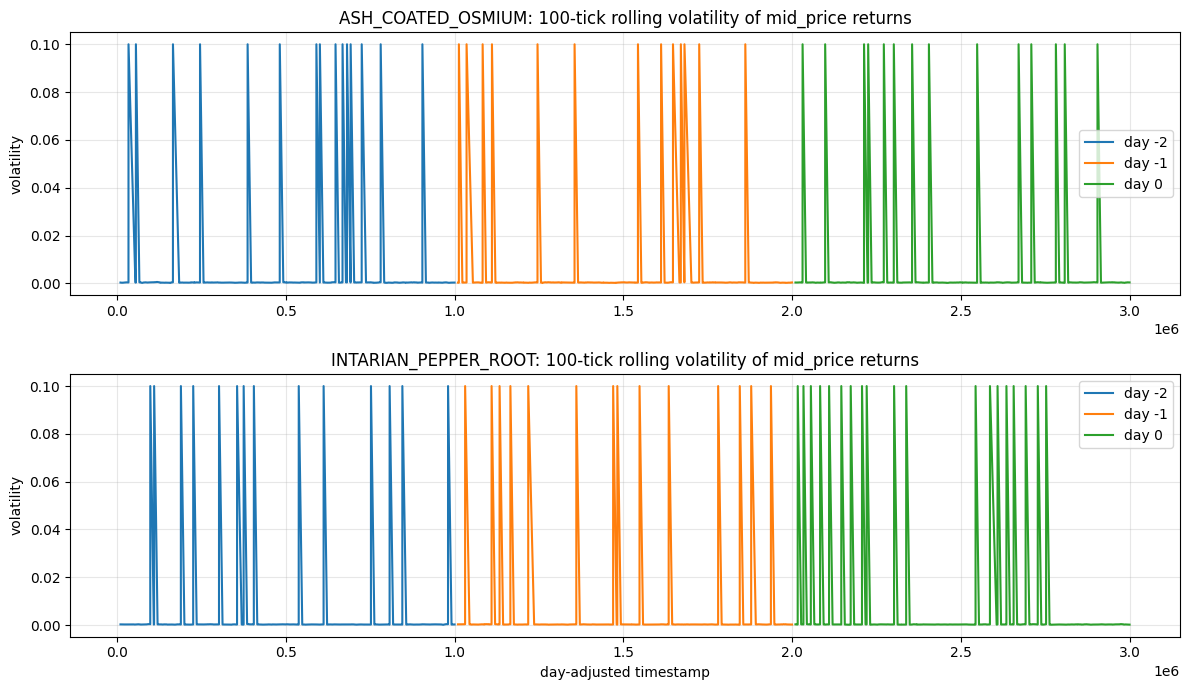

In [548]:
# Rolling volatility graph for round 1 products across days -2, -1, and 0
import pandas as pd
import matplotlib.pyplot as plt

price_paths = [
    "../datasets/round1/prices_round_1_day_-2.csv",
    "../datasets/round1/prices_round_1_day_-1.csv",
    "../datasets/round1/prices_round_1_day_0.csv",
]

prices = pd.concat([pd.read_csv(path, sep=";") for path in price_paths], ignore_index=True)
products = ["ASH_COATED_OSMIUM", "INTARIAN_PEPPER_ROOT"]
window = 100

fig, axes = plt.subplots(len(products), 1, figsize=(12, 7), sharex=False)

for ax, product in zip(axes, products):
    product_prices = prices[prices["product"] == product].sort_values(["day", "timestamp"]).copy()
    product_prices["global_timestamp"] = (product_prices["day"] + 2) * 1_000_000 + product_prices["timestamp"]
    product_prices["mid_return"] = product_prices.groupby("day")["mid_price"].pct_change()
    product_prices["rolling_volatility"] = (
        product_prices.groupby("day")["mid_return"]
        .rolling(window=window, min_periods=window)
        .std()
        .reset_index(level=0, drop=True)
    )

    product_prices = product_prices.dropna(subset=["rolling_volatility"])

    for day, day_prices in product_prices.groupby("day"):
        ax.plot(day_prices["global_timestamp"], day_prices["rolling_volatility"], label=f"day {day}")

    ax.set_title(f"{product}: {window}-tick rolling volatility of mid_price returns")
    ax.set_ylabel("volatility")
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("day-adjusted timestamp")
plt.tight_layout()
plt.show()


In [549]:
from scipy.stats import norm
from scipy.optimize import brentq
import numpy as np

def fair_price(S, K, T, r, sigma):
    """Black-Scholes call price. S=spot, K=strike, T=time to expiry (years), r=risk-free rate, sigma=annualised vol."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def implied_vol(market_price, S, K, T, r=0):
    """Invert BS to get implied vol. Returns NaN if no solution found."""
    intrinsic = max(S - K * np.exp(-r * T), 0)
    if market_price <= intrinsic:
        return np.nan
    try:
        return brentq(lambda sig: fair_price(S, K, T, r, sig) - market_price, 1e-6, 20)
    except ValueError:
        return np.nan

def rolling_iv(spot_series, voucher_series, K, T_series, recalc_every=50, r=0):
    """
    Solve IV every recalc_every ticks and carry it forward in between.
    Reduces brentq calls by recalc_every times vs solving every tick.
    """
    import pandas as pd

    n = len(voucher_series)
    fair_prices = np.full(n, np.nan)
    ivs = np.full(n, np.nan)
    current_iv = np.nan

    for i in range(n):
        if i % recalc_every == 0:
            iv = implied_vol(voucher_series.iloc[i], spot_series.iloc[i], K, T_series.iloc[i], r)
            if not np.isnan(iv):
                current_iv = iv

        if not np.isnan(current_iv):
            ivs[i] = current_iv
            fair_prices[i] = fair_price(spot_series.iloc[i], K, T_series.iloc[i], r, current_iv)

    return pd.Series(fair_prices, index=voucher_series.index), pd.Series(ivs, index=voucher_series.index)


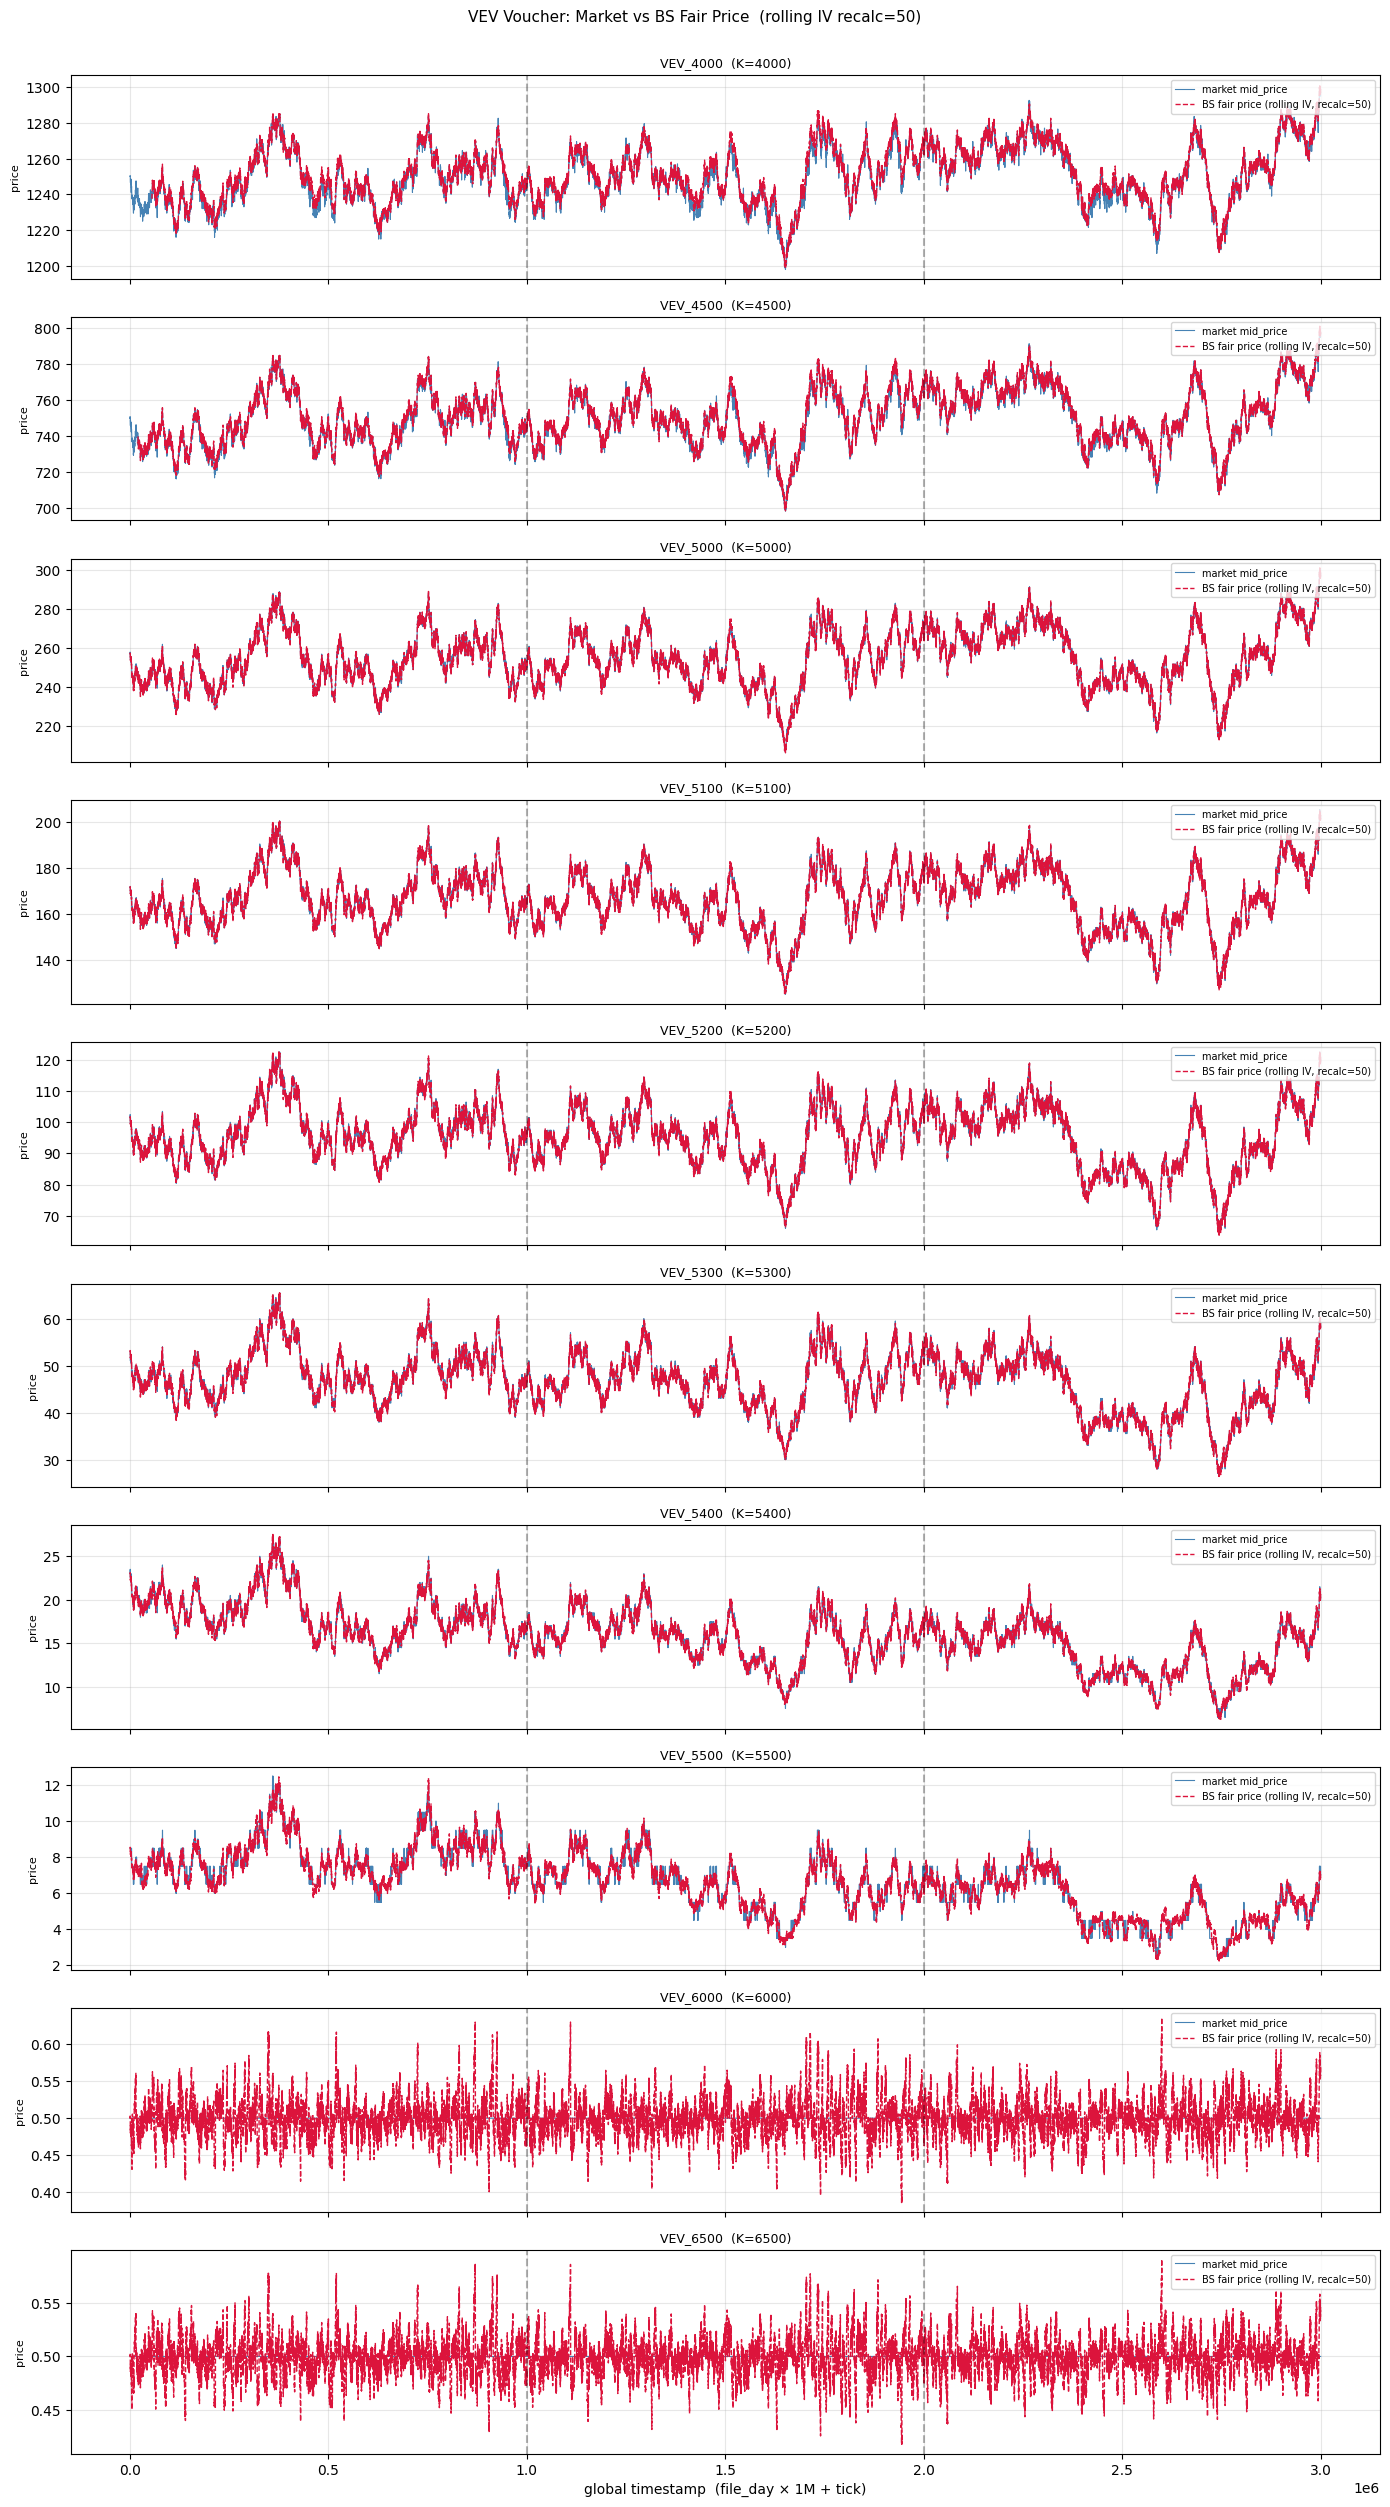

In [550]:
# Fair price using rolling IV for each voucher across all days
# File day 0 = competition day -2 (7 days to expiry)
# File day 1 = competition day -1 (6 days to expiry)
# File day 2 = competition day  0 (5 days to expiry)

TICKS_PER_DAY = 1_000_000
TRADING_DAYS_PER_YEAR = 252
EXPIRY_GLOBAL_TS = 7 * TICKS_PER_DAY

RECALC_EVERY = 50  # ticks to look back when estimating rolling IV

S_col = r3_prices[r3_prices["product"] == "VELVETFRUIT_EXTRACT"].copy()
S_col["global_ts"] = S_col["day"] * TICKS_PER_DAY + S_col["timestamp"]
S_col = S_col.sort_values("global_ts")[["global_ts", "mid_price"]].rename(columns={"mid_price": "spot"})

strikes = sorted(r3_vouchers["product"].unique(), key=lambda x: int(x.split("_")[1]))

fig, axes = plt.subplots(len(strikes), 1, figsize=(14, 2.5 * len(strikes)), sharex=True)

for ax, strike in zip(axes, strikes):
    K = int(strike.split("_")[1])
    df = r3_vouchers[r3_vouchers["product"] == strike].copy()
    df["global_ts"] = df["day"] * TICKS_PER_DAY + df["timestamp"]
    df = df.sort_values("global_ts").reset_index(drop=True)

    df = pd.merge_asof(df, S_col, on="global_ts", direction="nearest")
    df["T"] = (EXPIRY_GLOBAL_TS - df["global_ts"]) / TICKS_PER_DAY / TRADING_DAYS_PER_YEAR
    df = df[df["T"] > 0].reset_index(drop=True)

    bs_prices, ivs = rolling_iv(df["spot"], df["mid_price"], K, df["T"], recalc_every=RECALC_EVERY)

    ax.plot(df["global_ts"], df["mid_price"], color="steelblue", linewidth=0.8, label="market mid_price")
    ax.plot(df["global_ts"], bs_prices, color="crimson", linewidth=1.0, linestyle="--", label=f"BS fair price (rolling IV, recalc={RECALC_EVERY})")
    ax.set_title(f"{strike}  (K={K})", fontsize=9)
    ax.set_ylabel("price", fontsize=8)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)
    for day in [1, 2]:
        ax.axvline(x=day * TICKS_PER_DAY, color="black", linestyle="--", alpha=0.3)

axes[-1].set_xlabel("global timestamp  (file_day × 1M + tick)")
plt.suptitle(f"VEV Voucher: Market vs BS Fair Price  (rolling IV recalc={RECALC_EVERY})", fontsize=11, y=1.001)
plt.tight_layout()
plt.show()


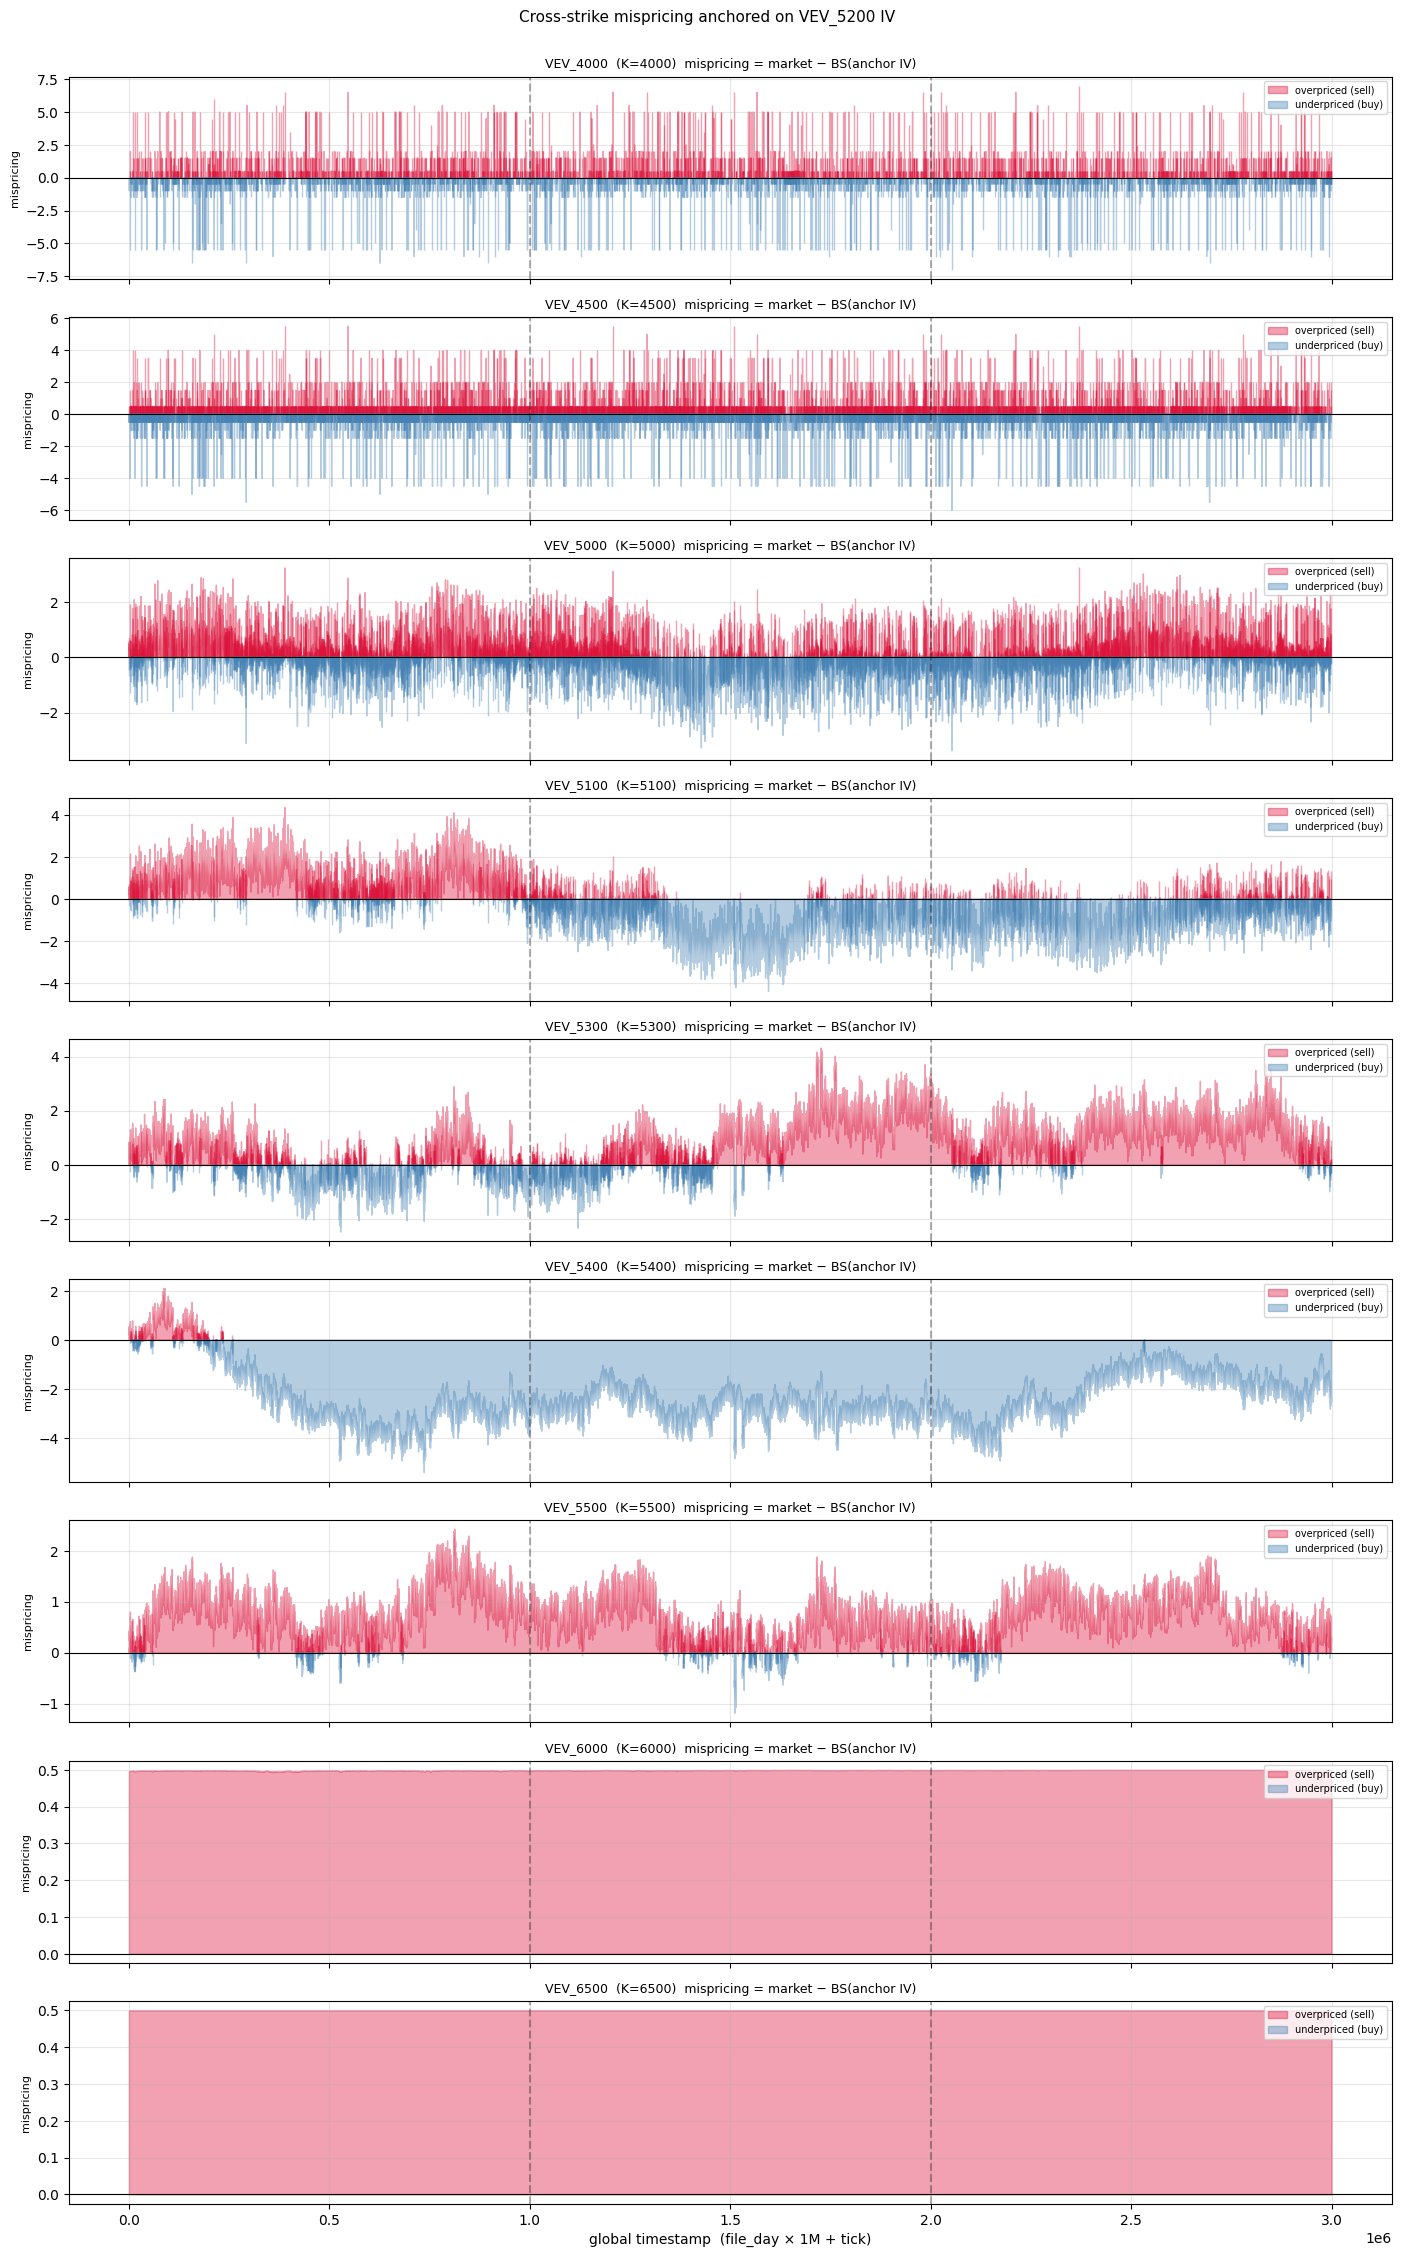

In [551]:
# Cross-strike mispricing: anchor IV on VEV_5200, price all other strikes with it
# If another strike's market price deviates from BS(anchor_IV), that is a real edge.
#
# HOW IT MAKES MONEY:
#   - If market > BS fair price: sell the voucher, delta-hedge with the underlying.
#     You collected more premium than the option is worth. As IV mean-reverts or the
#     option decays, you buy it back cheaper and pocket the difference.
#   - If market < BS fair price: buy the voucher, delta-hedge with the underlying.
#     You paid less than fair value. Same logic in reverse.
#   - Delta-hedging with VELVETFRUIT_EXTRACT neutralises directional spot risk,
#     leaving you with pure volatility / mispricing PnL.

TICKS_PER_DAY = 1_000_000
TRADING_DAYS_PER_YEAR = 252
EXPIRY_GLOBAL_TS = 7 * TICKS_PER_DAY
RECALC_EVERY = 50
ANCHOR_STRIKE = 5200

# Build spot series
S_col = r3_prices[r3_prices["product"] == "VELVETFRUIT_EXTRACT"].copy()
S_col["global_ts"] = S_col["day"] * TICKS_PER_DAY + S_col["timestamp"]
S_col = S_col.sort_values("global_ts")[["global_ts", "mid_price"]].rename(columns={"mid_price": "spot"})

# Build anchor IV series from VEV_5200
anchor = r3_vouchers[r3_vouchers["product"] == f"VEV_{ANCHOR_STRIKE}"].copy()
anchor["global_ts"] = anchor["day"] * TICKS_PER_DAY + anchor["timestamp"]
anchor = anchor.sort_values("global_ts").reset_index(drop=True)
anchor = pd.merge_asof(anchor, S_col, on="global_ts", direction="nearest")
anchor["T"] = (EXPIRY_GLOBAL_TS - anchor["global_ts"]) / TICKS_PER_DAY / TRADING_DAYS_PER_YEAR
anchor = anchor[anchor["T"] > 0].reset_index(drop=True)

_, anchor_ivs = rolling_iv(anchor["spot"], anchor["mid_price"], ANCHOR_STRIKE, anchor["T"], recalc_every=RECALC_EVERY)
anchor["iv"] = anchor_ivs.values

# For each non-anchor strike: merge anchor IV, compute BS fair price, plot mispricing
other_strikes = [s for s in sorted(r3_vouchers["product"].unique(), key=lambda x: int(x.split("_")[1]))
                 if int(s.split("_")[1]) != ANCHOR_STRIKE]

fig, axes = plt.subplots(len(other_strikes), 1, figsize=(14, 2.5 * len(other_strikes)), sharex=True)

for ax, strike in zip(axes, other_strikes):
    K = int(strike.split("_")[1])
    df = r3_vouchers[r3_vouchers["product"] == strike].copy()
    df["global_ts"] = df["day"] * TICKS_PER_DAY + df["timestamp"]
    df = df.sort_values("global_ts").reset_index(drop=True)
    df = pd.merge_asof(df, S_col, on="global_ts", direction="nearest")
    df["T"] = (EXPIRY_GLOBAL_TS - df["global_ts"]) / TICKS_PER_DAY / TRADING_DAYS_PER_YEAR
    df = df[df["T"] > 0].reset_index(drop=True)

    # Merge anchor IV by nearest global_ts
    df = pd.merge_asof(df.sort_values("global_ts"),
                       anchor[["global_ts", "iv"]].sort_values("global_ts"),
                       on="global_ts", direction="nearest")

    df["bs_price"] = df.apply(
        lambda row: fair_price(row["spot"], K, row["T"], 0, row["iv"])
        if not pd.isna(row["iv"]) else np.nan, axis=1)
    df["mispricing"] = df["mid_price"] - df["bs_price"]

    ax.axhline(0, color="black", linewidth=0.8)
    ax.fill_between(df["global_ts"], df["mispricing"], 0,
                    where=df["mispricing"] > 0, color="crimson", alpha=0.4, label="overpriced (sell)")
    ax.fill_between(df["global_ts"], df["mispricing"], 0,
                    where=df["mispricing"] < 0, color="steelblue", alpha=0.4, label="underpriced (buy)")
    ax.set_title(f"{strike}  (K={K})  mispricing = market − BS(anchor IV)", fontsize=9)
    ax.set_ylabel("mispricing", fontsize=8)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)
    for day in [1, 2]:
        ax.axvline(x=day * TICKS_PER_DAY, color="black", linestyle="--", alpha=0.3)

axes[-1].set_xlabel("global timestamp  (file_day × 1M + tick)")
plt.suptitle(f"Cross-strike mispricing anchored on VEV_{ANCHOR_STRIKE} IV", fontsize=11, y=1.001)
plt.tight_layout()
plt.show()


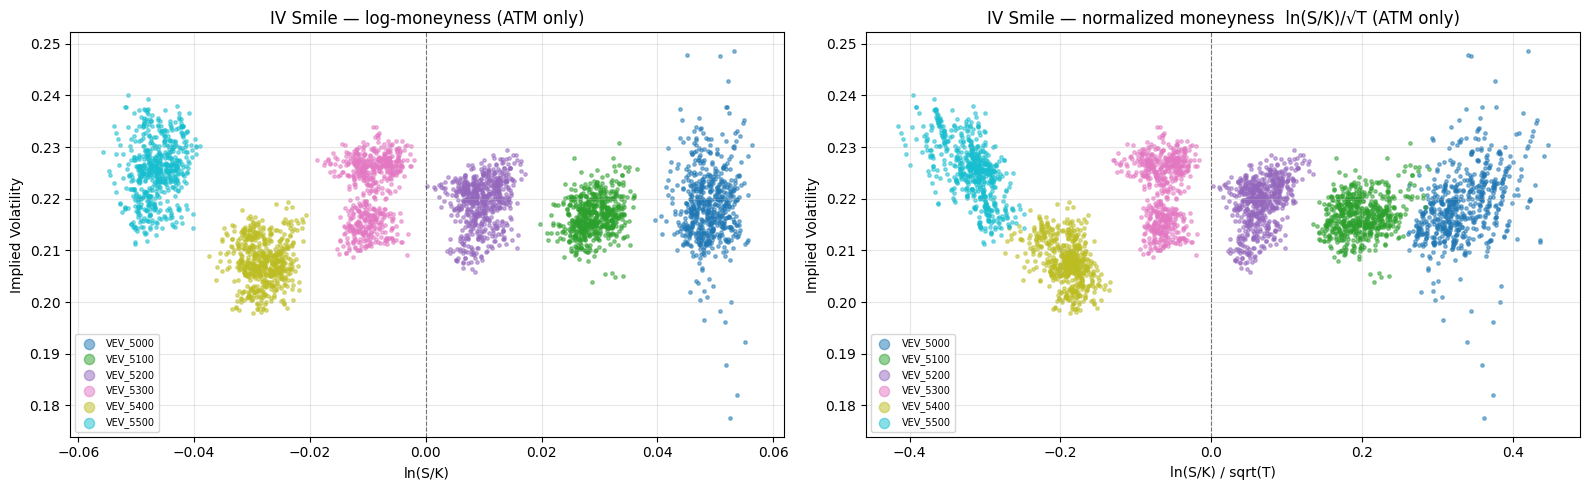

In [552]:
# IV smile: implied vol vs ln(S/K) / sqrt(T) — ATM strikes only (5000-5500)

TICKS_PER_DAY = 1_000_000
TRADING_DAYS_PER_YEAR = 252
EXPIRY_GLOBAL_TS = 7 * TICKS_PER_DAY
RECALC_EVERY = 50

PLOT_STRIKES = [5000, 5100, 5200, 5300, 5400, 5500]

S_col = r3_prices[r3_prices["product"] == "VELVETFRUIT_EXTRACT"].copy()
S_col["global_ts"] = S_col["day"] * TICKS_PER_DAY + S_col["timestamp"]
S_col = S_col.sort_values("global_ts")[["global_ts", "mid_price"]].rename(columns={"mid_price": "spot"})

colors = plt.cm.tab10(np.linspace(0, 1, len(PLOT_STRIKES)))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for strike_int, color in zip(PLOT_STRIKES, colors):
    strike = f"VEV_{strike_int}"
    K = strike_int
    df = r3_vouchers[r3_vouchers["product"] == strike].copy()
    df["global_ts"] = df["day"] * TICKS_PER_DAY + df["timestamp"]
    df = df.sort_values("global_ts").reset_index(drop=True)
    df = pd.merge_asof(df, S_col, on="global_ts", direction="nearest")
    df["T"] = (EXPIRY_GLOBAL_TS - df["global_ts"]) / TICKS_PER_DAY / TRADING_DAYS_PER_YEAR
    df = df[df["T"] > 0].reset_index(drop=True)

    rows = df.iloc[::RECALC_EVERY]
    ivs, log_m, norm_m = [], [], []
    for _, row in rows.iterrows():
        iv = implied_vol(row["mid_price"], row["spot"], K, row["T"])
        if not np.isnan(iv) and row["T"] > 0:
            lm = np.log(row["spot"] / K)
            ivs.append(iv)
            log_m.append(lm)
            norm_m.append(lm / np.sqrt(row["T"]))

    axes[0].scatter(log_m,  ivs, s=6, alpha=0.5, color=color, label=strike)
    axes[1].scatter(norm_m, ivs, s=6, alpha=0.5, color=color, label=strike)

for ax, xlabel, title in zip(axes,
    ["ln(S/K)", "ln(S/K) / sqrt(T)"],
    ["IV Smile — log-moneyness (ATM only)", "IV Smile — normalized moneyness  ln(S/K)/√T (ATM only)"]):
    ax.axvline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Implied Volatility")
    ax.set_title(title)
    ax.legend(fontsize=7, markerscale=3)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


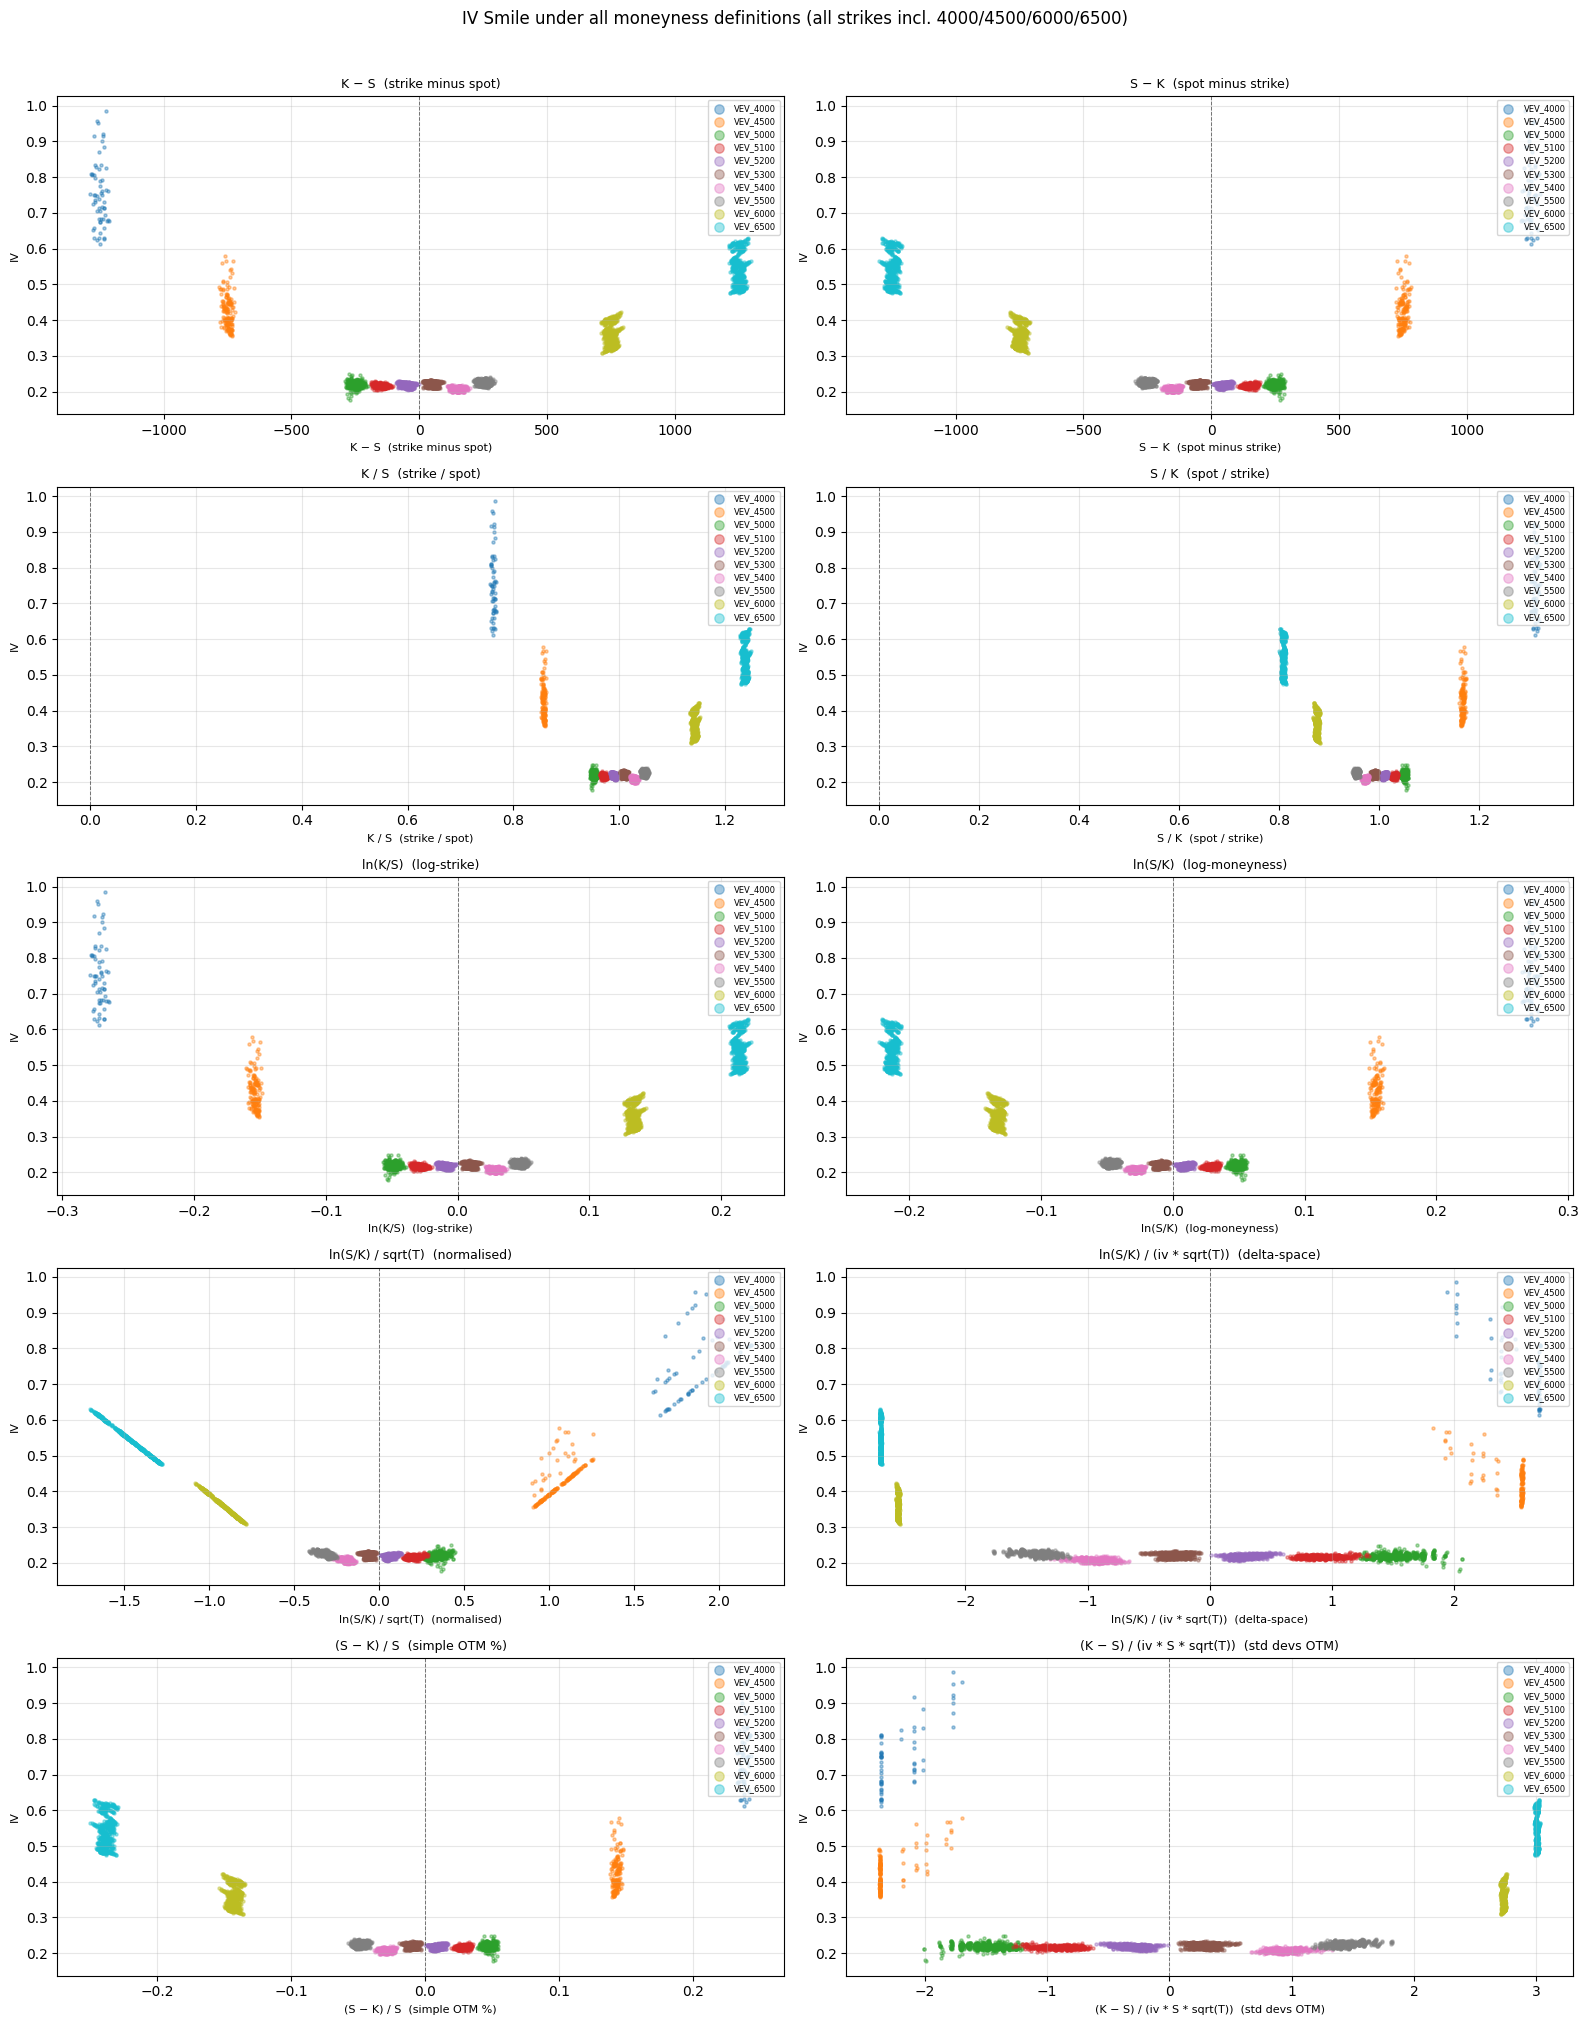

In [553]:
# IV smile under all common moneyness definitions
# For each definition, scatter IV vs moneyness for all strikes including far contracts

TICKS_PER_DAY        = 1_000_000
TRADING_DAYS_PER_YEAR = 252
EXPIRY_GLOBAL_TS      = 7 * TICKS_PER_DAY
RECALC_EVERY          = 50
PLOT_STRIKES          = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]

S_col = r3_prices[r3_prices["product"] == "VELVETFRUIT_EXTRACT"].copy()
S_col["global_ts"] = S_col["day"] * TICKS_PER_DAY + S_col["timestamp"]
S_col = S_col.sort_values("global_ts")[["global_ts", "mid_price"]].rename(columns={"mid_price": "spot"})

# Collect (iv, S, K, T) every RECALC_EVERY ticks for each strike
records = []
for K in PLOT_STRIKES:
    sym = f"VEV_{K}"
    if sym not in r3_vouchers["product"].values:
        continue
    df = r3_vouchers[r3_vouchers["product"] == sym].copy()
    df["global_ts"] = df["day"] * TICKS_PER_DAY + df["timestamp"]
    df = df.sort_values("global_ts").reset_index(drop=True)
    df = pd.merge_asof(df, S_col, on="global_ts", direction="nearest")
    df["T"] = (EXPIRY_GLOBAL_TS - df["global_ts"]) / TICKS_PER_DAY / TRADING_DAYS_PER_YEAR
    df = df[df["T"] > 0].reset_index(drop=True)
    for i, row in df.iloc[::RECALC_EVERY].iterrows():
        iv = implied_vol(row["mid_price"], row["spot"], K, row["T"])
        if not np.isnan(iv):
            records.append({"K": K, "S": row["spot"], "T": row["T"], "iv": iv})

df_all = pd.DataFrame(records)
df_all["F"] = df_all["S"]   # forward ≈ spot (r=0)

present_strikes = sorted(df_all["K"].unique())

# All moneyness definitions
moneyness_defs = {
    "K − S  (strike minus spot)": lambda r: r["K"] - r["S"],
    "S − K  (spot minus strike)": lambda r: r["S"] - r["K"],
    "K / S  (strike / spot)": lambda r: r["K"] / r["S"],
    "S / K  (spot / strike)": lambda r: r["S"] / r["K"],
    "ln(K/S)  (log-strike)": lambda r: np.log(r["K"] / r["S"]),
    "ln(S/K)  (log-moneyness)": lambda r: np.log(r["S"] / r["K"]),
    "ln(S/K) / sqrt(T)  (normalised)": lambda r: np.log(r["S"] / r["K"]) / np.sqrt(r["T"]),
    "ln(S/K) / (iv * sqrt(T))  (delta-space)": lambda r: np.log(r["S"] / r["K"]) / (r["iv"] * np.sqrt(r["T"])),
    "(S − K) / S  (simple OTM %)": lambda r: (r["S"] - r["K"]) / r["S"],
    "(K − S) / (iv * S * sqrt(T))  (std devs OTM)": lambda r: (r["K"] - r["S"]) / (r["iv"] * r["S"] * np.sqrt(r["T"])),
}

colors = plt.cm.tab10(np.linspace(0, 1, len(present_strikes)))
n_defs = len(moneyness_defs)
ncols = 2
nrows = (n_defs + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for ax, (label, fn) in zip(axes, moneyness_defs.items()):
    df_all["m"] = df_all.apply(fn, axis=1)
    for K, color in zip(present_strikes, colors):
        sub = df_all[df_all["K"] == K]
        ax.scatter(sub["m"], sub["iv"], s=5, alpha=0.4, color=color, label=f"VEV_{K}")
    ax.axvline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.5)
    ax.set_xlabel(label, fontsize=8)
    ax.set_ylabel("IV", fontsize=8)
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=6, markerscale=3, loc="upper right")
    ax.grid(True, alpha=0.3)

# hide any unused axes
for ax in axes[n_defs:]:
    ax.set_visible(False)

plt.suptitle("IV Smile under all moneyness definitions (all strikes incl. 4000/4500/6000/6500)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


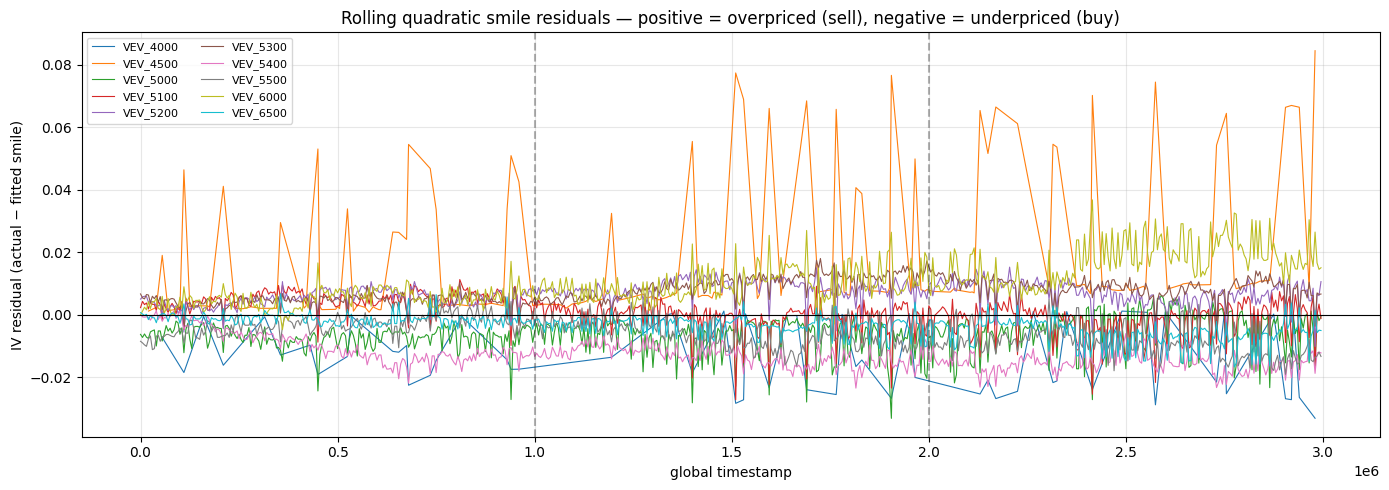

Mean |residual| per strike:
K
4000.0    0.01376
4500.0    0.01779
5000.0    0.00693
5100.0    0.00427
5200.0    0.00702
5300.0    0.00766
5400.0    0.01267
5500.0    0.00632
6000.0    0.01068
6500.0    0.00390
Name: residual, dtype: float64


In [554]:
# Rolling quadratic smile fit: residual IV per strike
# At each recalc tick, fit a quadratic to IV vs moneyness across all strikes.
# Residual = actual IV - fitted IV. Large residual = mispriced.

TICKS_PER_DAY = 1_000_000
TRADING_DAYS_PER_YEAR = 252
EXPIRY_GLOBAL_TS = 7 * TICKS_PER_DAY
RECALC_EVERY = 50

S_col = r3_prices[r3_prices["product"] == "VELVETFRUIT_EXTRACT"].copy()
S_col["global_ts"] = S_col["day"] * TICKS_PER_DAY + S_col["timestamp"]
S_col = S_col.sort_values("global_ts")[["global_ts","mid_price"]].rename(columns={"mid_price":"spot"})

strikes = sorted(r3_vouchers["product"].unique(), key=lambda x: int(x.split("_")[1]))
strike_ints = [int(s.split("_")[1]) for s in strikes]

# Build aligned df: one row per (tick, strike) at recalc ticks only
dfs = {}
for strike, K in zip(strikes, strike_ints):
    df = r3_vouchers[r3_vouchers["product"] == strike].copy()
    df["global_ts"] = df["day"] * TICKS_PER_DAY + df["timestamp"]
    df = df.sort_values("global_ts").reset_index(drop=True)
    df = pd.merge_asof(df, S_col, on="global_ts", direction="nearest")
    df["T"] = (EXPIRY_GLOBAL_TS - df["global_ts"]) / TICKS_PER_DAY / TRADING_DAYS_PER_YEAR
    df = df[df["T"] > 0].reset_index(drop=True)
    df = df.iloc[::RECALC_EVERY].copy()
    df["K"] = K
    df["moneyness"] = np.log(df["spot"] / K)
    df["iv"] = [implied_vol(row["mid_price"], row["spot"], K, row["T"])
                for _, row in df.iterrows()]
    dfs[K] = df[["global_ts","moneyness","iv","K"]].reset_index(drop=True)

# Merge all strikes on global_ts
all_df = pd.concat(dfs.values(), ignore_index=True).dropna(subset=["iv"])

# At each timestamp, fit quadratic to (moneyness, iv) across all strikes, compute residuals
timestamps = sorted(all_df["global_ts"].unique())
records = []
for ts in timestamps:
    snap = all_df[all_df["global_ts"] == ts]
    if len(snap) < 4:
        continue
    m = snap["moneyness"].values
    iv = snap["iv"].values
    coeffs = np.polyfit(m, iv, deg=2)
    fitted = np.polyval(coeffs, m)
    for (_, row), fit in zip(snap.iterrows(), fitted):
        records.append({"global_ts": ts, "K": row["K"], "residual": row["iv"] - fit, "iv": row["iv"]})

resid_df = pd.DataFrame(records)

# Plot residuals per strike
colors = plt.cm.tab10(np.linspace(0, 1, len(strikes)))
fig, ax = plt.subplots(figsize=(14, 5))

for (K, color) in zip(strike_ints, colors):
    sub = resid_df[resid_df["K"] == K].sort_values("global_ts")
    ax.plot(sub["global_ts"], sub["residual"], linewidth=0.8, color=color, label=f"VEV_{K}")

ax.axhline(0, color="black", linewidth=0.8)
ax.fill_between(resid_df["global_ts"].unique(),
                 resid_df.groupby("global_ts")["residual"].mean().values,
                 0, alpha=0.05, color="gray")
for day in [1, 2]:
    ax.axvline(x=day * TICKS_PER_DAY, color="black", linestyle="--", alpha=0.3)
ax.set_xlabel("global timestamp")
ax.set_ylabel("IV residual (actual − fitted smile)")
ax.set_title("Rolling quadratic smile residuals — positive = overpriced (sell), negative = underpriced (buy)")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Also print mean absolute residual per strike as a summary
print("Mean |residual| per strike:")
print(resid_df.groupby("K")["residual"].apply(lambda x: x.abs().mean()).round(5))


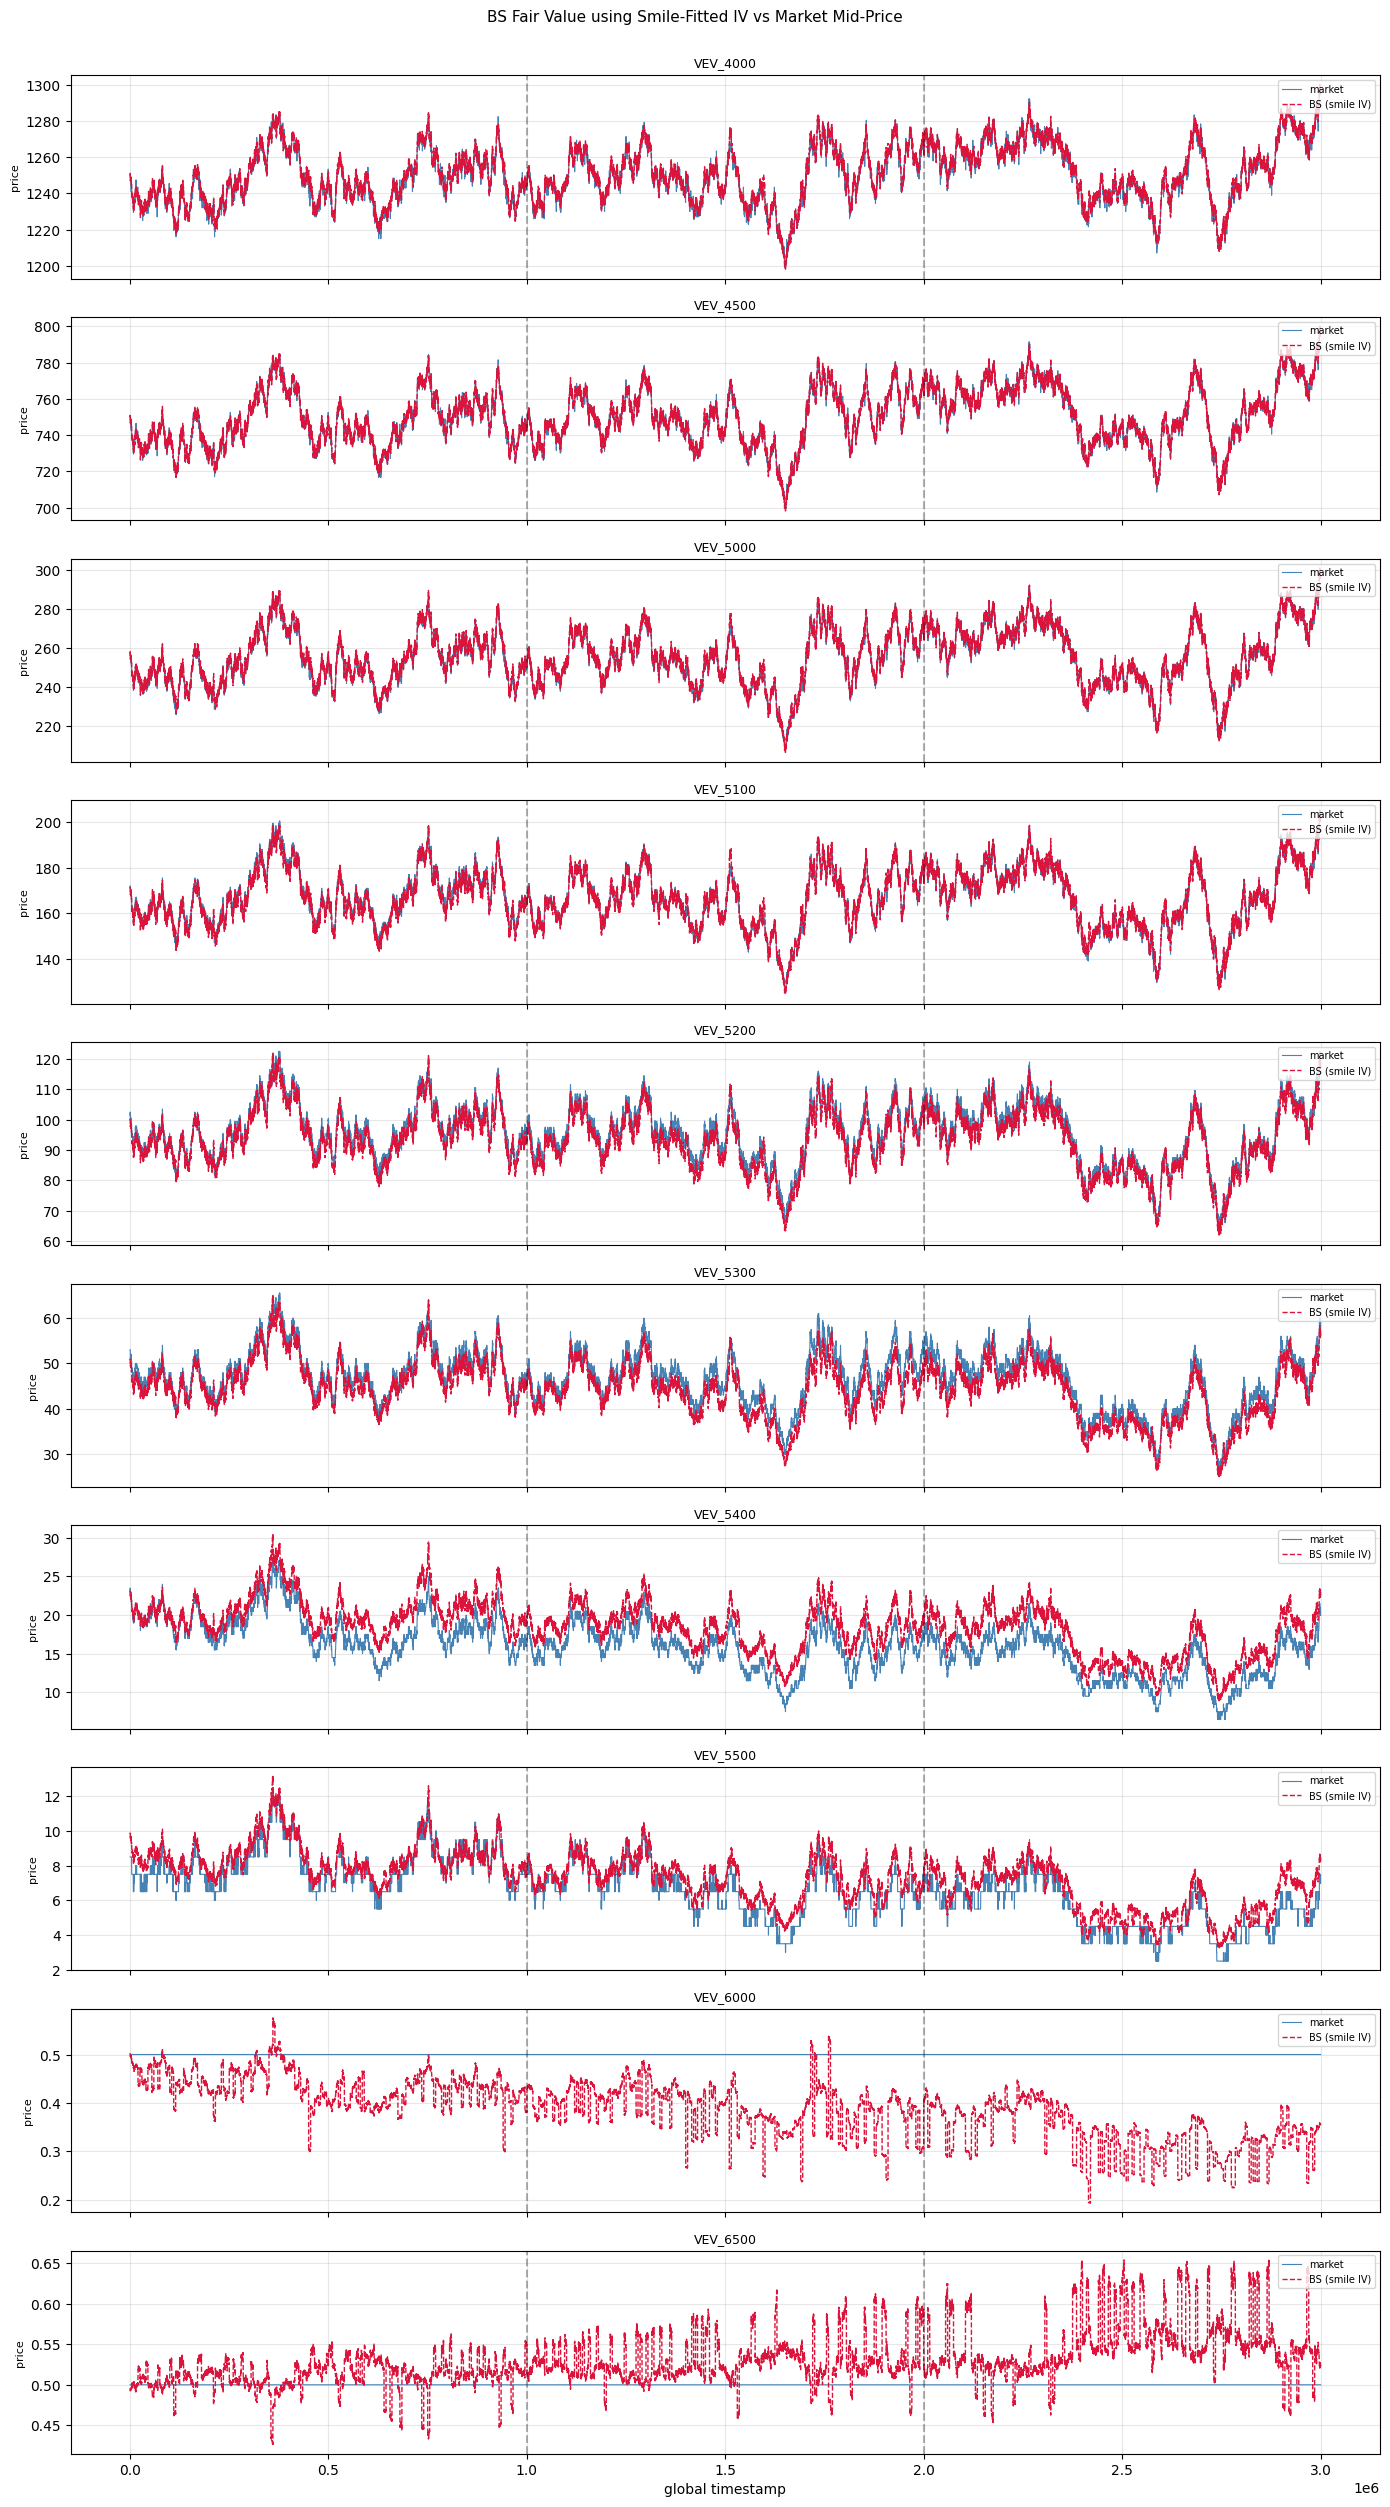

In [555]:
# BS fair value using smile-fitted IV for each voucher
# At each recalc tick: fit quadratic smile across all strikes, price each with its smile IV

TICKS_PER_DAY = 1_000_000
TRADING_DAYS_PER_YEAR = 252
EXPIRY_GLOBAL_TS = 7 * TICKS_PER_DAY
RECALC_EVERY = 50

S_col = r3_prices[r3_prices["product"] == "VELVETFRUIT_EXTRACT"].copy()
S_col["global_ts"] = S_col["day"] * TICKS_PER_DAY + S_col["timestamp"]
S_col = S_col.sort_values("global_ts")[["global_ts","mid_price"]].rename(columns={"mid_price":"spot"})

strikes = sorted(r3_vouchers["product"].unique(), key=lambda x: int(x.split("_")[1]))
strike_ints = [int(s.split("_")[1]) for s in strikes]

# Build per-strike dataframes at all ticks
dfs = {}
for K in strike_ints:
    df = r3_vouchers[r3_vouchers["product"] == f"VEV_{K}"].copy()
    df["global_ts"] = df["day"] * TICKS_PER_DAY + df["timestamp"]
    df = df.sort_values("global_ts").reset_index(drop=True)
    df = pd.merge_asof(df, S_col, on="global_ts", direction="nearest")
    df["T"] = (EXPIRY_GLOBAL_TS - df["global_ts"]) / TICKS_PER_DAY / TRADING_DAYS_PER_YEAR
    df = df[df["T"] > 0].reset_index(drop=True)
    df["log_moneyness"] = np.log(df["spot"] / K)
    df["K"] = K
    dfs[K] = df

# At each recalc tick, fit quadratic smile and carry forward to all ticks
recalc_ticks = sorted(dfs[strike_ints[0]].iloc[::RECALC_EVERY]["global_ts"].values)

# Build smile_iv lookup: {global_ts -> coeffs}
smile_coeffs = {}
for ts in recalc_ticks:
    ivs, lms = [], []
    for K in strike_ints:
        df = dfs[K]
        row = df[df["global_ts"] == ts]
        if row.empty:
            row = df.iloc[(df["global_ts"] - ts).abs().argmin()]
        else:
            row = row.iloc[0]
        iv = implied_vol(row["mid_price"], row["spot"], K, row["T"])
        if not np.isnan(iv):
            ivs.append(iv)
            lms.append(row["log_moneyness"])
    if len(ivs) >= 4:
        smile_coeffs[ts] = np.polyfit(lms, ivs, deg=2)

# For each strike, compute smile fair price at every tick
colors = plt.cm.tab10(np.linspace(0, 1, len(strikes)))
fig, axes = plt.subplots(len(strike_ints), 1, figsize=(14, 2.5 * len(strike_ints)), sharex=True)

for ax, K, color in zip(axes, strike_ints, colors):
    df = dfs[K].copy()
    smile_fair = np.full(len(df), np.nan)
    last_coeffs = None

    for i, row in df.iterrows():
        ts = row["global_ts"]
        # update coeffs at recalc ticks
        nearest = min(smile_coeffs.keys(), key=lambda t: abs(t - ts)) if smile_coeffs else None
        if nearest is not None and nearest <= ts:
            last_coeffs = smile_coeffs[nearest]
        if last_coeffs is not None:
            smile_iv = np.polyval(last_coeffs, row["log_moneyness"])
            if smile_iv > 0:
                smile_fair[i] = fair_price(row["spot"], K, row["T"], 0, smile_iv)

    ax.plot(df["global_ts"], df["mid_price"], color="steelblue", linewidth=0.8, label="market")
    ax.plot(df["global_ts"], smile_fair, color="crimson", linewidth=1.0, linestyle="--", label="BS (smile IV)")
    ax.set_title(f"VEV_{K}", fontsize=9)
    ax.set_ylabel("price", fontsize=8)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)
    for day in [1, 2]:
        ax.axvline(x=day * TICKS_PER_DAY, color="black", linestyle="--", alpha=0.3)

axes[-1].set_xlabel("global timestamp")
plt.suptitle("BS Fair Value using Smile-Fitted IV vs Market Mid-Price", fontsize=11, y=1.001)
plt.tight_layout()
plt.show()


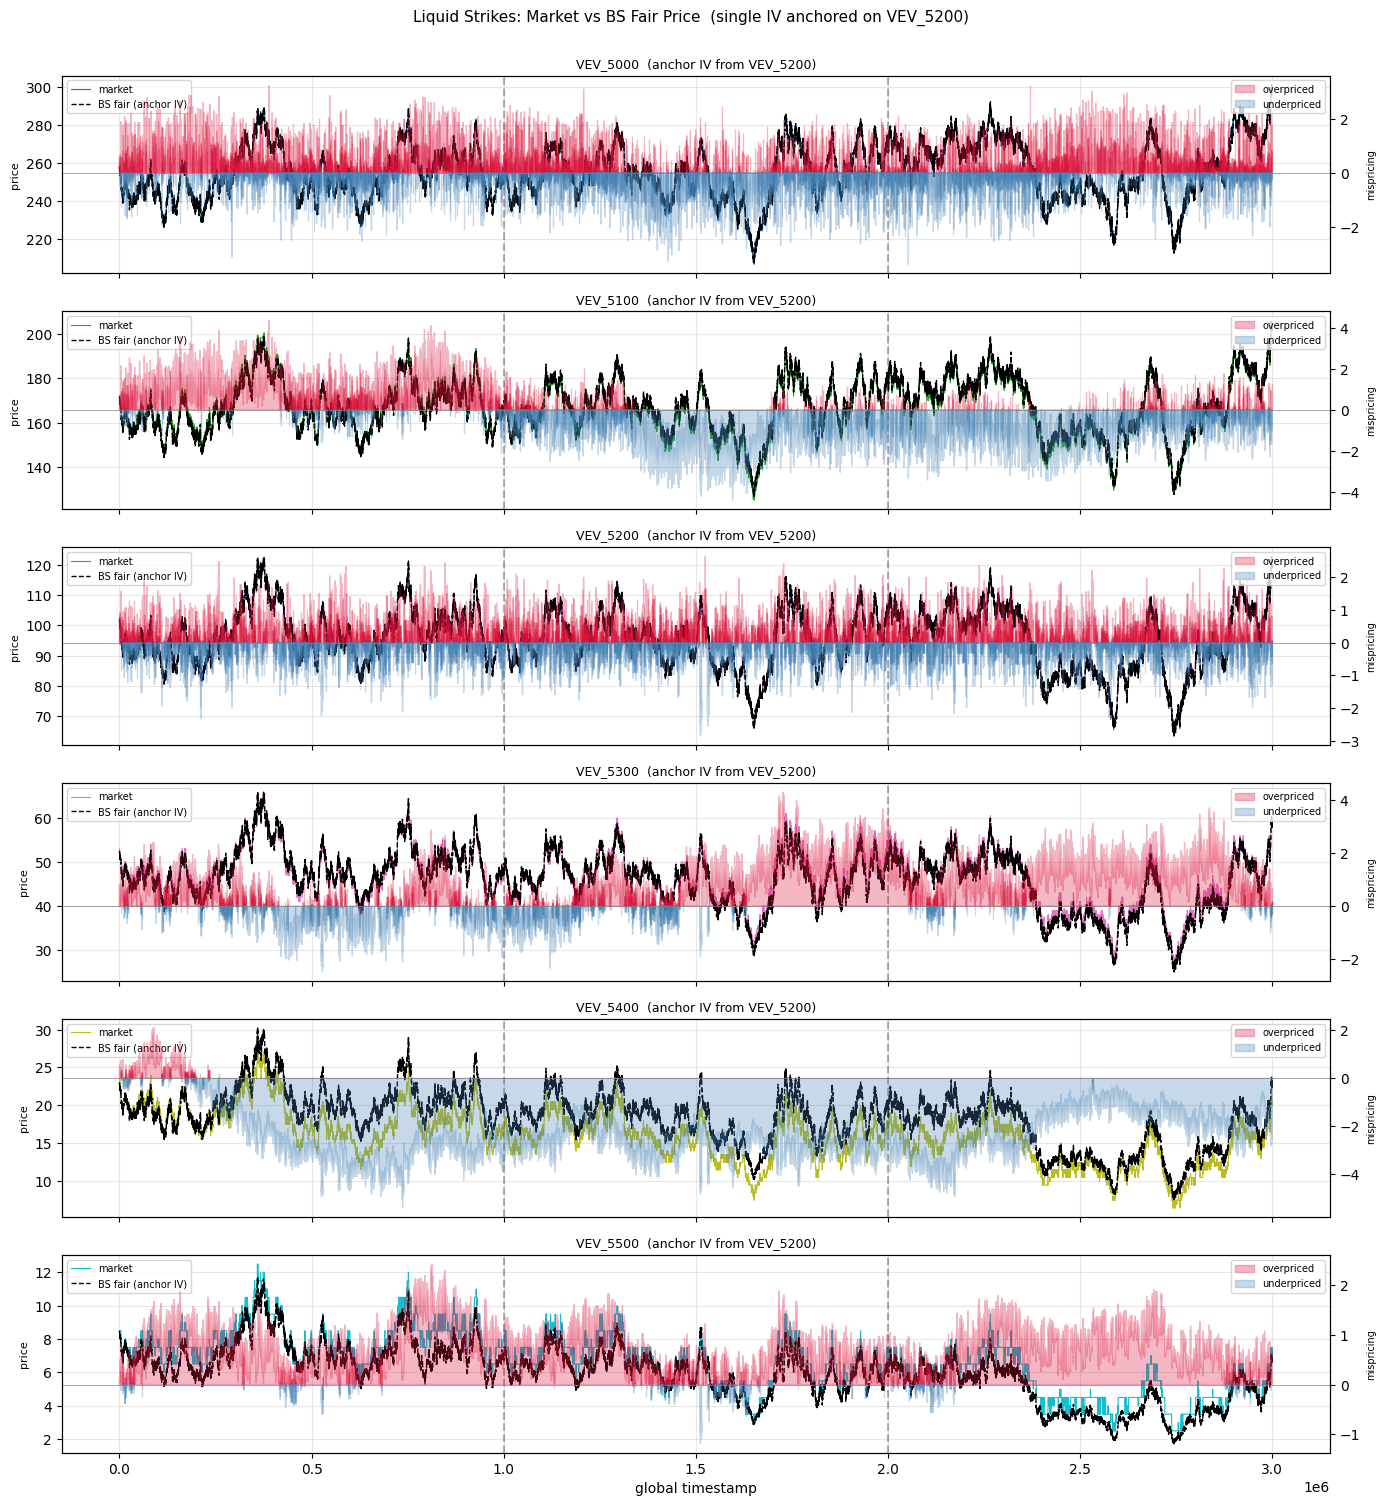

In [556]:
# Single-IV BS fair price for liquid strikes (VEV_5000 to VEV_5500)
# IV anchored on VEV_5200, carried forward every RECALC_EVERY ticks

TICKS_PER_DAY = 1_000_000
TRADING_DAYS_PER_YEAR = 252
EXPIRY_GLOBAL_TS = 7 * TICKS_PER_DAY
RECALC_EVERY = 50
ANCHOR_STRIKE = 5200
LIQUID_STRIKES = [5000, 5100, 5200, 5300, 5400, 5500]

S_col = r3_prices[r3_prices["product"] == "VELVETFRUIT_EXTRACT"].copy()
S_col["global_ts"] = S_col["day"] * TICKS_PER_DAY + S_col["timestamp"]
S_col = S_col.sort_values("global_ts")[["global_ts","mid_price"]].rename(columns={"mid_price":"spot"})

# Build anchor IV series from VEV_5200
anchor = r3_vouchers[r3_vouchers["product"] == f"VEV_{ANCHOR_STRIKE}"].copy()
anchor["global_ts"] = anchor["day"] * TICKS_PER_DAY + anchor["timestamp"]
anchor = anchor.sort_values("global_ts").reset_index(drop=True)
anchor = pd.merge_asof(anchor, S_col, on="global_ts", direction="nearest")
anchor["T"] = (EXPIRY_GLOBAL_TS - anchor["global_ts"]) / TICKS_PER_DAY / TRADING_DAYS_PER_YEAR
anchor = anchor[anchor["T"] > 0].reset_index(drop=True)

# Solve anchor IV every RECALC_EVERY ticks, carry forward
anchor_iv_series = np.full(len(anchor), np.nan)
current_iv = np.nan
for i, row in anchor.iterrows():
    if i % RECALC_EVERY == 0:
        iv = implied_vol(row["mid_price"], row["spot"], ANCHOR_STRIKE, row["T"])
        if not np.isnan(iv):
            current_iv = iv
    anchor_iv_series[i] = current_iv
anchor["iv"] = anchor_iv_series

# Plot each liquid strike
fig, axes = plt.subplots(len(LIQUID_STRIKES), 1, figsize=(14, 2.5 * len(LIQUID_STRIKES)), sharex=True)
colors = plt.cm.tab10(np.linspace(0, 1, len(LIQUID_STRIKES)))

for ax, K, color in zip(axes, LIQUID_STRIKES, colors):
    df = r3_vouchers[r3_vouchers["product"] == f"VEV_{K}"].copy()
    df["global_ts"] = df["day"] * TICKS_PER_DAY + df["timestamp"]
    df = df.sort_values("global_ts").reset_index(drop=True)
    df = pd.merge_asof(df, S_col, on="global_ts", direction="nearest")
    df["T"] = (EXPIRY_GLOBAL_TS - df["global_ts"]) / TICKS_PER_DAY / TRADING_DAYS_PER_YEAR
    df = df[df["T"] > 0].reset_index(drop=True)

    # Merge anchor IV
    df = pd.merge_asof(df, anchor[["global_ts","iv"]], on="global_ts", direction="nearest")
    df["bs_price"] = df.apply(
        lambda r: fair_price(r["spot"], K, r["T"], 0, r["iv"]) if not np.isnan(r["iv"]) else np.nan, axis=1)
    df["mispricing"] = df["mid_price"] - df["bs_price"]

    ax2 = ax.twinx()
    ax.plot(df["global_ts"], df["mid_price"], color=color, linewidth=0.8, label="market")
    ax.plot(df["global_ts"], df["bs_price"], color="black", linewidth=1.0, linestyle="--", label="BS fair (anchor IV)")
    ax2.fill_between(df["global_ts"], df["mispricing"], 0,
                     where=df["mispricing"] > 0, color="crimson", alpha=0.3, label="overpriced")
    ax2.fill_between(df["global_ts"], df["mispricing"], 0,
                     where=df["mispricing"] < 0, color="steelblue", alpha=0.3, label="underpriced")
    ax2.set_ylabel("mispricing", fontsize=7)
    ax2.axhline(0, color="gray", linewidth=0.5)
    ax.set_title(f"VEV_{K}  (anchor IV from VEV_{ANCHOR_STRIKE})", fontsize=9)
    ax.set_ylabel("price", fontsize=8)
    ax.legend(fontsize=7, loc="upper left")
    ax2.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)
    for day in [1, 2]:
        ax.axvline(x=day * TICKS_PER_DAY, color="black", linestyle="--", alpha=0.3)

axes[-1].set_xlabel("global timestamp")
plt.suptitle(f"Liquid Strikes: Market vs BS Fair Price  (single IV anchored on VEV_{ANCHOR_STRIKE})", fontsize=11, y=1.001)
plt.tight_layout()
plt.show()


VEV_5000: mean_resid=0.0381  std_resid=0.7172  max_abs=4.2169
VEV_5100: mean_resid=0.0379  std_resid=0.6136  max_abs=3.4431
VEV_5200: mean_resid=0.0224  std_resid=0.5331  max_abs=2.8605
VEV_5300: mean_resid=0.0268  std_resid=0.4246  max_abs=1.9233


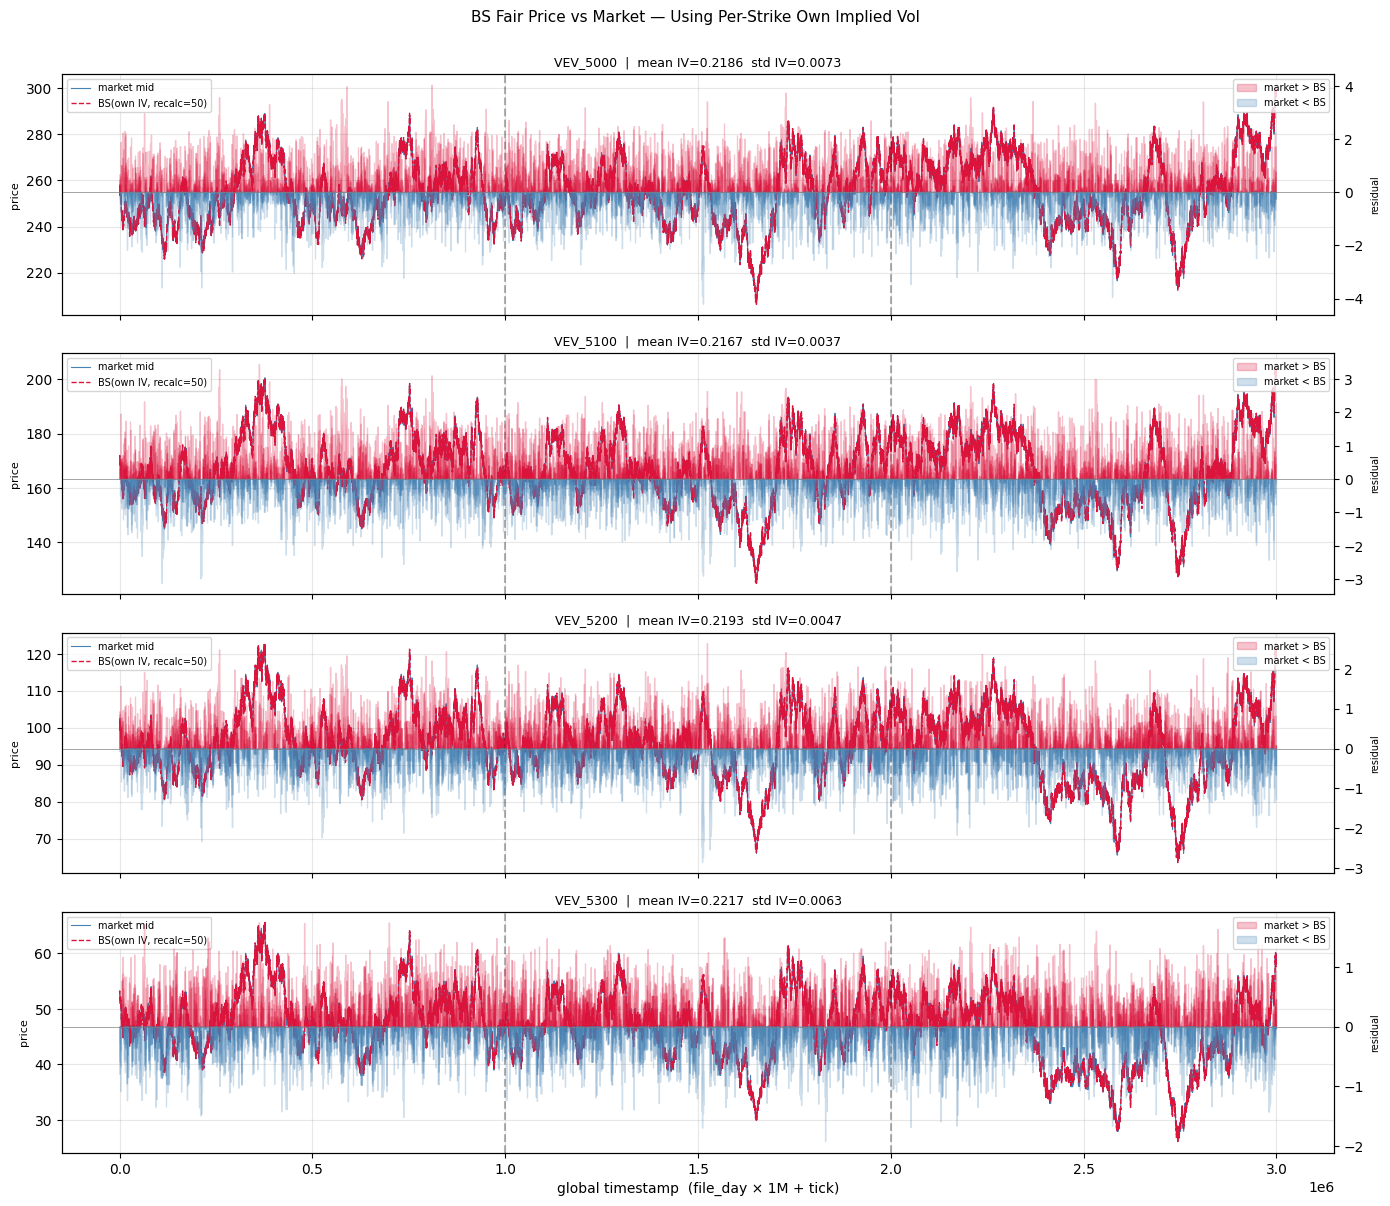

In [557]:
# Per-strike implied vol: solve IV from each option's own market price, then plot BS fair price vs market
# This is the tightest possible fit — using each strike's own IV means BS(own_iv) ≈ market by construction.
# Any remaining gap reveals model error (early exercise, jumps, liquidity) rather than cross-strike mispricing.

TICKS_PER_DAY = 1_000_000
TRADING_DAYS_PER_YEAR = 252
EXPIRY_GLOBAL_TS = 7 * TICKS_PER_DAY
RECALC_EVERY = 50
LIQUID_STRIKES = [5000, 5100, 5200, 5300]

S_col = r3_prices[r3_prices["product"] == "VELVETFRUIT_EXTRACT"].copy()
S_col["global_ts"] = S_col["day"] * TICKS_PER_DAY + S_col["timestamp"]
S_col = S_col.sort_values("global_ts")[["global_ts", "mid_price"]].rename(columns={"mid_price": "spot"})

fig, axes = plt.subplots(len(LIQUID_STRIKES), 1, figsize=(14, 3 * len(LIQUID_STRIKES)), sharex=True)

for ax, K in zip(axes, LIQUID_STRIKES):
    df = r3_vouchers[r3_vouchers["product"] == f"VEV_{K}"].copy()
    df["global_ts"] = df["day"] * TICKS_PER_DAY + df["timestamp"]
    df = df.sort_values("global_ts").reset_index(drop=True)
    df = pd.merge_asof(df, S_col, on="global_ts", direction="nearest")
    df["T"] = (EXPIRY_GLOBAL_TS - df["global_ts"]) / TICKS_PER_DAY / TRADING_DAYS_PER_YEAR
    df = df[df["T"] > 0].reset_index(drop=True)

    # Solve IV from this strike's own market price every RECALC_EVERY ticks, carry forward
    own_iv = np.full(len(df), np.nan)
    bs_fair = np.full(len(df), np.nan)
    current_iv = np.nan
    for i, row in df.iterrows():
        if i % RECALC_EVERY == 0:
            iv = implied_vol(row["mid_price"], row["spot"], K, row["T"])
            if not np.isnan(iv):
                current_iv = iv
        own_iv[i] = current_iv
        if not np.isnan(current_iv) and row["T"] > 0:
            bs_fair[i] = fair_price(row["spot"], K, row["T"], 0, current_iv)

    df["own_iv"] = own_iv
    df["bs_fair"] = bs_fair
    df["residual"] = df["mid_price"] - df["bs_fair"]

    ax2 = ax.twinx()
    ax.plot(df["global_ts"], df["mid_price"], color="steelblue", linewidth=0.8, label="market mid")
    ax.plot(df["global_ts"], df["bs_fair"], color="crimson", linewidth=1.0, linestyle="--", label=f"BS(own IV, recalc={RECALC_EVERY})")
    ax2.fill_between(df["global_ts"], df["residual"], 0,
                     where=df["residual"] > 0, color="crimson", alpha=0.25, label="market > BS")
    ax2.fill_between(df["global_ts"], df["residual"], 0,
                     where=df["residual"] < 0, color="steelblue", alpha=0.25, label="market < BS")
    ax2.axhline(0, color="gray", linewidth=0.5)
    ax2.set_ylabel("residual", fontsize=7)

    ax.set_title(f"VEV_{K}  |  mean IV={np.nanmean(own_iv):.4f}  std IV={np.nanstd(own_iv):.4f}", fontsize=9)
    ax.set_ylabel("price", fontsize=8)
    ax.legend(fontsize=7, loc="upper left")
    ax2.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)
    for day in [1, 2]:
        ax.axvline(x=day * TICKS_PER_DAY, color="black", linestyle="--", alpha=0.3)

    residuals_clean = df["residual"].dropna()
    print(f"VEV_{K}: mean_resid={residuals_clean.mean():.4f}  std_resid={residuals_clean.std():.4f}  max_abs={residuals_clean.abs().max():.4f}")

axes[-1].set_xlabel("global timestamp  (file_day × 1M + tick)")
plt.suptitle("BS Fair Price vs Market — Using Per-Strike Own Implied Vol", fontsize=11, y=1.001)
plt.tight_layout()
plt.show()


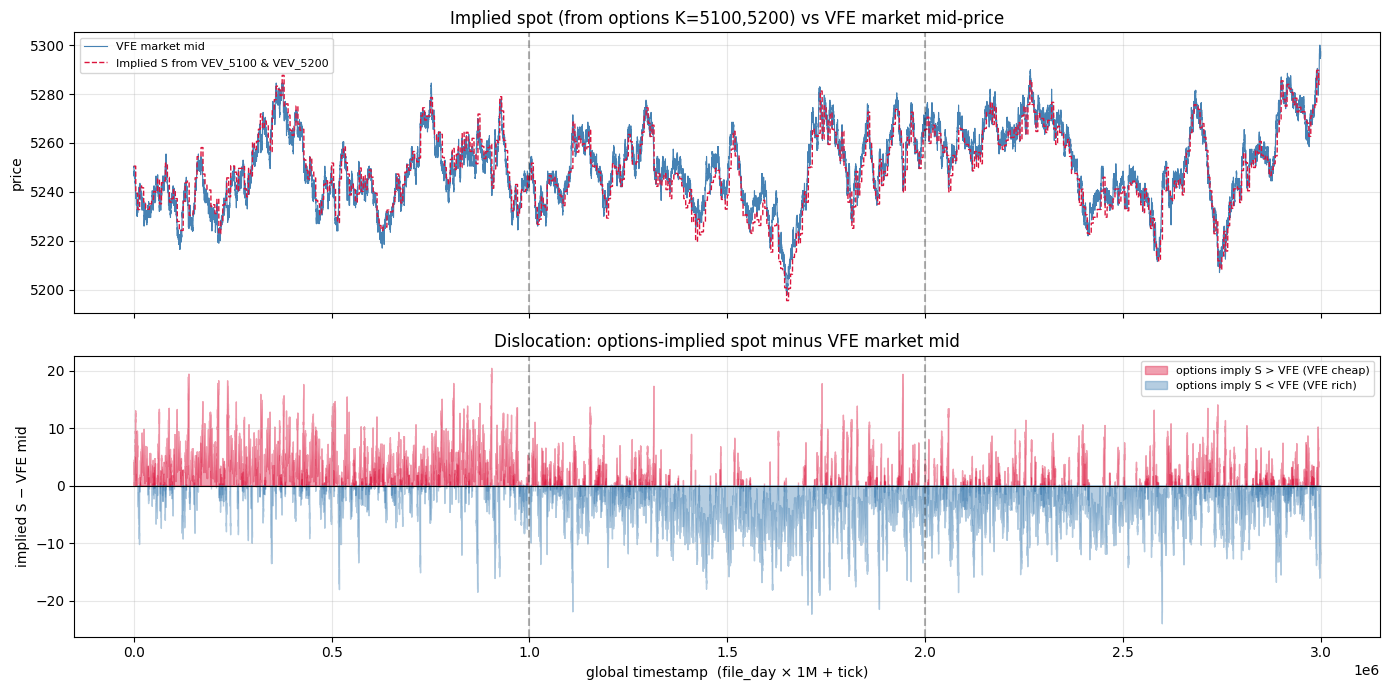

Dislocation  mean=-1.071  std=5.563  max=20.390  min=-23.967
Fraction where |dislocation| > 1: 85.8%
Fraction where |dislocation| > 3: 58.4%


In [558]:
# Implied spot from options: solve (S, sigma) jointly from two strikes (5100 & 5200)
# Two equations: BS(S, K1, T, sigma) = mkt_K1 and BS(S, K2, T, sigma) = mkt_K2
# Solve numerically every RECALC_EVERY ticks; carry forward between solves.
# Compare implied S against VFE market mid-price to detect dislocations.

from scipy.optimize import fsolve
import warnings

TICKS_PER_DAY   = 1_000_000
TRADING_DAYS_PER_YEAR = 252
EXPIRY_GLOBAL_TS = 7 * TICKS_PER_DAY
RECALC_EVERY    = 50
K1, K2          = 5100, 5200   # two liquid strikes to anchor the solve

# Build aligned time series for K1 and K2
def build_series(K):
    df = r3_vouchers[r3_vouchers["product"] == f"VEV_{K}"].copy()
    df["global_ts"] = df["day"] * TICKS_PER_DAY + df["timestamp"]
    df["T"] = (EXPIRY_GLOBAL_TS - df["global_ts"]) / TICKS_PER_DAY / TRADING_DAYS_PER_YEAR
    return df[df["T"] > 0].sort_values("global_ts").reset_index(drop=True)[["global_ts", "mid_price", "T"]]

df1 = build_series(K1).rename(columns={"mid_price": "mkt1", "T": "T1"})
df2 = build_series(K2).rename(columns={"mid_price": "mkt2", "T": "T2"})

# Merge on nearest global_ts
merged = pd.merge_asof(df1, df2, on="global_ts", direction="nearest")

# VFE market mid
vfe = r3_prices[r3_prices["product"] == "VELVETFRUIT_EXTRACT"].copy()
vfe["global_ts"] = vfe["day"] * TICKS_PER_DAY + vfe["timestamp"]
vfe = vfe.sort_values("global_ts")[["global_ts", "mid_price"]].rename(columns={"mid_price": "vfe_mid"})
merged = pd.merge_asof(merged, vfe, on="global_ts", direction="nearest")

# Solve (S, sigma) jointly every RECALC_EVERY ticks
implied_spots = np.full(len(merged), np.nan)
last_S, last_sig = merged["vfe_mid"].iloc[0], 0.27   # warm start

for i, row in merged.iterrows():
    if i % RECALC_EVERY != 0:
        implied_spots[i] = last_S
        continue

    T = row["T1"]
    if T <= 0:
        implied_spots[i] = last_S
        continue

    def equations(x):
        S_guess, sig_guess = x
        if S_guess <= 0 or sig_guess <= 0:
            return [1e6, 1e6]
        e1 = fair_price(S_guess, K1, T, 0, sig_guess) - row["mkt1"]
        e2 = fair_price(S_guess, K2, T, 0, sig_guess) - row["mkt2"]
        return [e1, e2]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            sol, info, ier, msg = fsolve(equations, [last_S, last_sig], full_output=True)
            if ier == 1 and sol[0] > 0 and sol[1] > 0:
                last_S, last_sig = sol[0], sol[1]
        except Exception:
            pass

    implied_spots[i] = last_S

merged["implied_S"] = implied_spots
merged["dislocation"]  = merged["implied_S"] - merged["vfe_mid"]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(merged["global_ts"], merged["vfe_mid"],    color="steelblue",  linewidth=0.8, label="VFE market mid")
ax1.plot(merged["global_ts"], merged["implied_S"],  color="crimson",    linewidth=1.0, linestyle="--", label=f"Implied S from VEV_{K1} & VEV_{K2}")
ax1.set_ylabel("price")
ax1.set_title(f"Implied spot (from options K={K1},{K2}) vs VFE market mid-price")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
for day in [1, 2]:
    ax1.axvline(x=day * TICKS_PER_DAY, color="black", linestyle="--", alpha=0.3)

ax2.axhline(0, color="black", linewidth=0.8)
ax2.fill_between(merged["global_ts"], merged["dislocation"], 0,
                 where=merged["dislocation"] > 0, color="crimson",   alpha=0.4, label="options imply S > VFE (VFE cheap)")
ax2.fill_between(merged["global_ts"], merged["dislocation"], 0,
                 where=merged["dislocation"] < 0, color="steelblue", alpha=0.4, label="options imply S < VFE (VFE rich)")
ax2.set_ylabel("implied S − VFE mid")
ax2.set_title("Dislocation: options-implied spot minus VFE market mid")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
for day in [1, 2]:
    ax2.axvline(x=day * TICKS_PER_DAY, color="black", linestyle="--", alpha=0.3)

ax2.set_xlabel("global timestamp  (file_day × 1M + tick)")
plt.tight_layout()
plt.show()

# Summary stats
d = merged["dislocation"].dropna()
print(f"Dislocation  mean={d.mean():.3f}  std={d.std():.3f}  max={d.max():.3f}  min={d.min():.3f}")
print(f"Fraction where |dislocation| > 1: {(d.abs()>1).mean()*100:.1f}%")
print(f"Fraction where |dislocation| > 3: {(d.abs()>3).mean()*100:.1f}%")


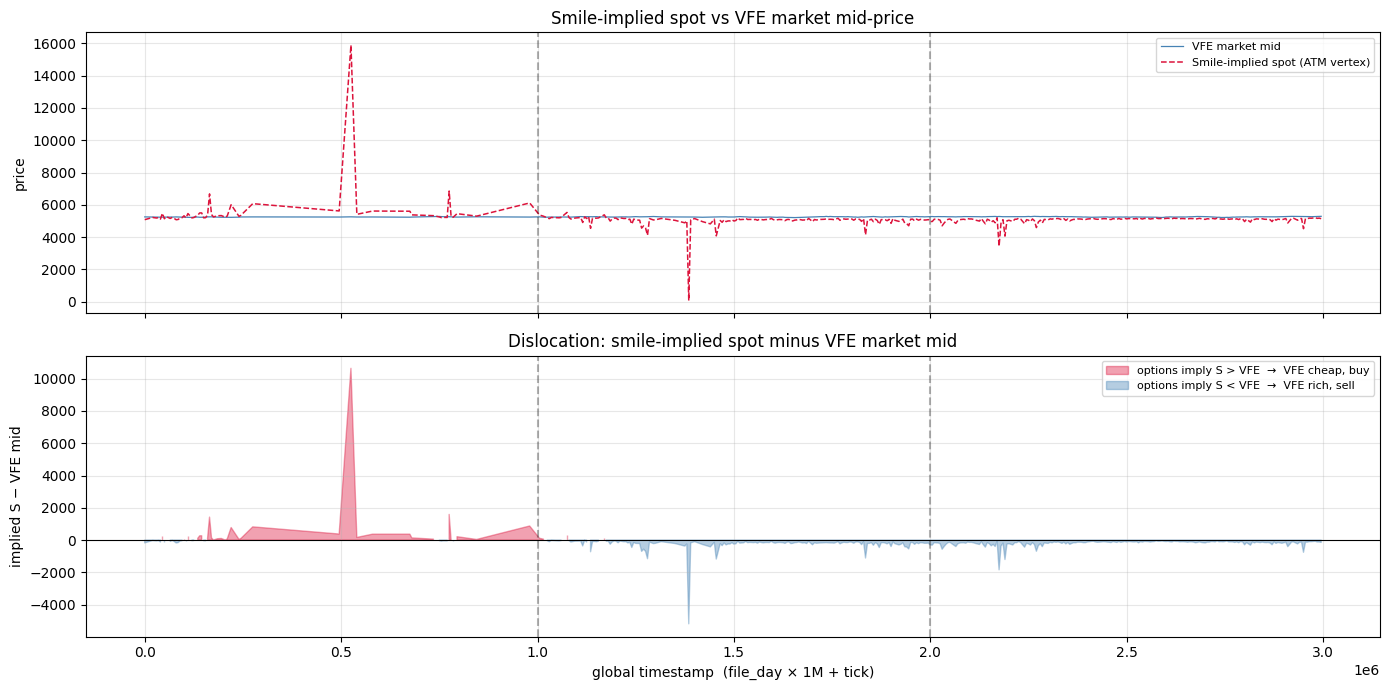

Dislocation  mean=-128.278  std=639.610  max=10641.707  min=-5184.406
|dislocation| > 1:  99.8%
|dislocation| > 3:  99.8%
|dislocation| > 5:  99.3%


In [559]:
# Implied spot from smile minimum: fit quadratic IV smile, find ATM vertex = implied S
# smile minimum occurs at log_moneyness* = -b/(2a)  →  implied_S = K_ref * exp(lm*)
# Plot implied S vs VFE mid-price; dislocation = implied_S - vfe_mid

TICKS_PER_DAY        = 1_000_000
TRADING_DAYS_PER_YEAR = 252
EXPIRY_GLOBAL_TS      = 7 * TICKS_PER_DAY
RECALC_EVERY          = 50
SMILE_STRIKES         = [5000, 5100, 5200, 5300]   # liquid strikes for smile fit

S_col = r3_prices[r3_prices["product"] == "VELVETFRUIT_EXTRACT"].copy()
S_col["global_ts"] = S_col["day"] * TICKS_PER_DAY + S_col["timestamp"]
S_col = S_col.sort_values("global_ts")[["global_ts", "mid_price"]].rename(columns={"mid_price": "spot"})

# Build per-strike series merged with spot
dfs = {}
for K in SMILE_STRIKES:
    df = r3_vouchers[r3_vouchers["product"] == f"VEV_{K}"].copy()
    df["global_ts"] = df["day"] * TICKS_PER_DAY + df["timestamp"]
    df = df.sort_values("global_ts").reset_index(drop=True)
    df = pd.merge_asof(df, S_col, on="global_ts", direction="nearest")
    df["T"] = (EXPIRY_GLOBAL_TS - df["global_ts"]) / TICKS_PER_DAY / TRADING_DAYS_PER_YEAR
    dfs[K] = df[df["T"] > 0].reset_index(drop=True)

# Use the timestamps of the most liquid strike (5200) as the recalc grid
ref_ts = dfs[5200].iloc[::RECALC_EVERY]["global_ts"].values

records = []
for ts in ref_ts:
    ivs, lms = [], []
    for K in SMILE_STRIKES:
        df = dfs[K]
        idx = (df["global_ts"] - ts).abs().argmin()
        row = df.iloc[idx]
        if row["T"] <= 0:
            continue
        iv = implied_vol(row["mid_price"], row["spot"], K, row["T"])
        if not np.isnan(iv):
            lm = np.log(row["spot"] / K)
            ivs.append(iv)
            lms.append(lm)

    if len(ivs) < 3:
        continue

    # quadratic fit: iv = a*lm^2 + b*lm + c
    a, b, c = np.polyfit(lms, ivs, deg=2)
    if a <= 0:          # not a proper U-shape, skip
        continue

    # vertex = smile minimum  →  implied ATM log-moneyness
    lm_star = -b / (2 * a)

    # implied_S from each strike independently, then average for robustness
    implied_Ss = [K * np.exp(lm_star + np.log(row["spot"] / K) - np.log(row["spot"] / K))
                  for K in SMILE_STRIKES]
    # cleaner: lm_star = log(spot/K_eff)  →  K_eff = spot / exp(lm_star)
    # use the 5200 row spot as reference
    ref_row = dfs[5200].iloc[(dfs[5200]["global_ts"] - ts).abs().argmin()]
    implied_S = ref_row["spot"] * np.exp(-lm_star)   # lm* = log(spot/K*), so K* = spot/exp(lm*)

    vfe_mid = ref_row["spot"]
    records.append({
        "global_ts":  ts,
        "implied_S":  implied_S,
        "vfe_mid":    vfe_mid,
        "lm_star":    lm_star,
        "smile_a":    a, "smile_b": b, "smile_c": c,
    })

smile_df = pd.DataFrame(records)
smile_df["dislocation"] = smile_df["implied_S"] - smile_df["vfe_mid"]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(smile_df["global_ts"], smile_df["vfe_mid"],   color="steelblue", linewidth=0.9, label="VFE market mid")
ax1.plot(smile_df["global_ts"], smile_df["implied_S"], color="crimson",   linewidth=1.1, linestyle="--", label="Smile-implied spot (ATM vertex)")
ax1.set_ylabel("price")
ax1.set_title("Smile-implied spot vs VFE market mid-price")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
for day in [1, 2]:
    ax1.axvline(x=day * TICKS_PER_DAY, color="black", linestyle="--", alpha=0.3)

ax2.axhline(0, color="black", linewidth=0.8)
ax2.fill_between(smile_df["global_ts"], smile_df["dislocation"], 0,
                 where=smile_df["dislocation"] > 0, color="crimson",   alpha=0.4, label="options imply S > VFE  →  VFE cheap, buy")
ax2.fill_between(smile_df["global_ts"], smile_df["dislocation"], 0,
                 where=smile_df["dislocation"] < 0, color="steelblue", alpha=0.4, label="options imply S < VFE  →  VFE rich, sell")
ax2.set_ylabel("implied S − VFE mid")
ax2.set_title("Dislocation: smile-implied spot minus VFE market mid")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
for day in [1, 2]:
    ax2.axvline(x=day * TICKS_PER_DAY, color="black", linestyle="--", alpha=0.3)

ax2.set_xlabel("global timestamp  (file_day × 1M + tick)")
plt.tight_layout()
plt.show()

d = smile_df["dislocation"].dropna()
print(f"Dislocation  mean={d.mean():.3f}  std={d.std():.3f}  max={d.max():.3f}  min={d.min():.3f}")
print(f"|dislocation| > 1:  {(d.abs()>1).mean()*100:.1f}%")
print(f"|dislocation| > 3:  {(d.abs()>3).mean()*100:.1f}%")
print(f"|dislocation| > 5:  {(d.abs()>5).mean()*100:.1f}%")


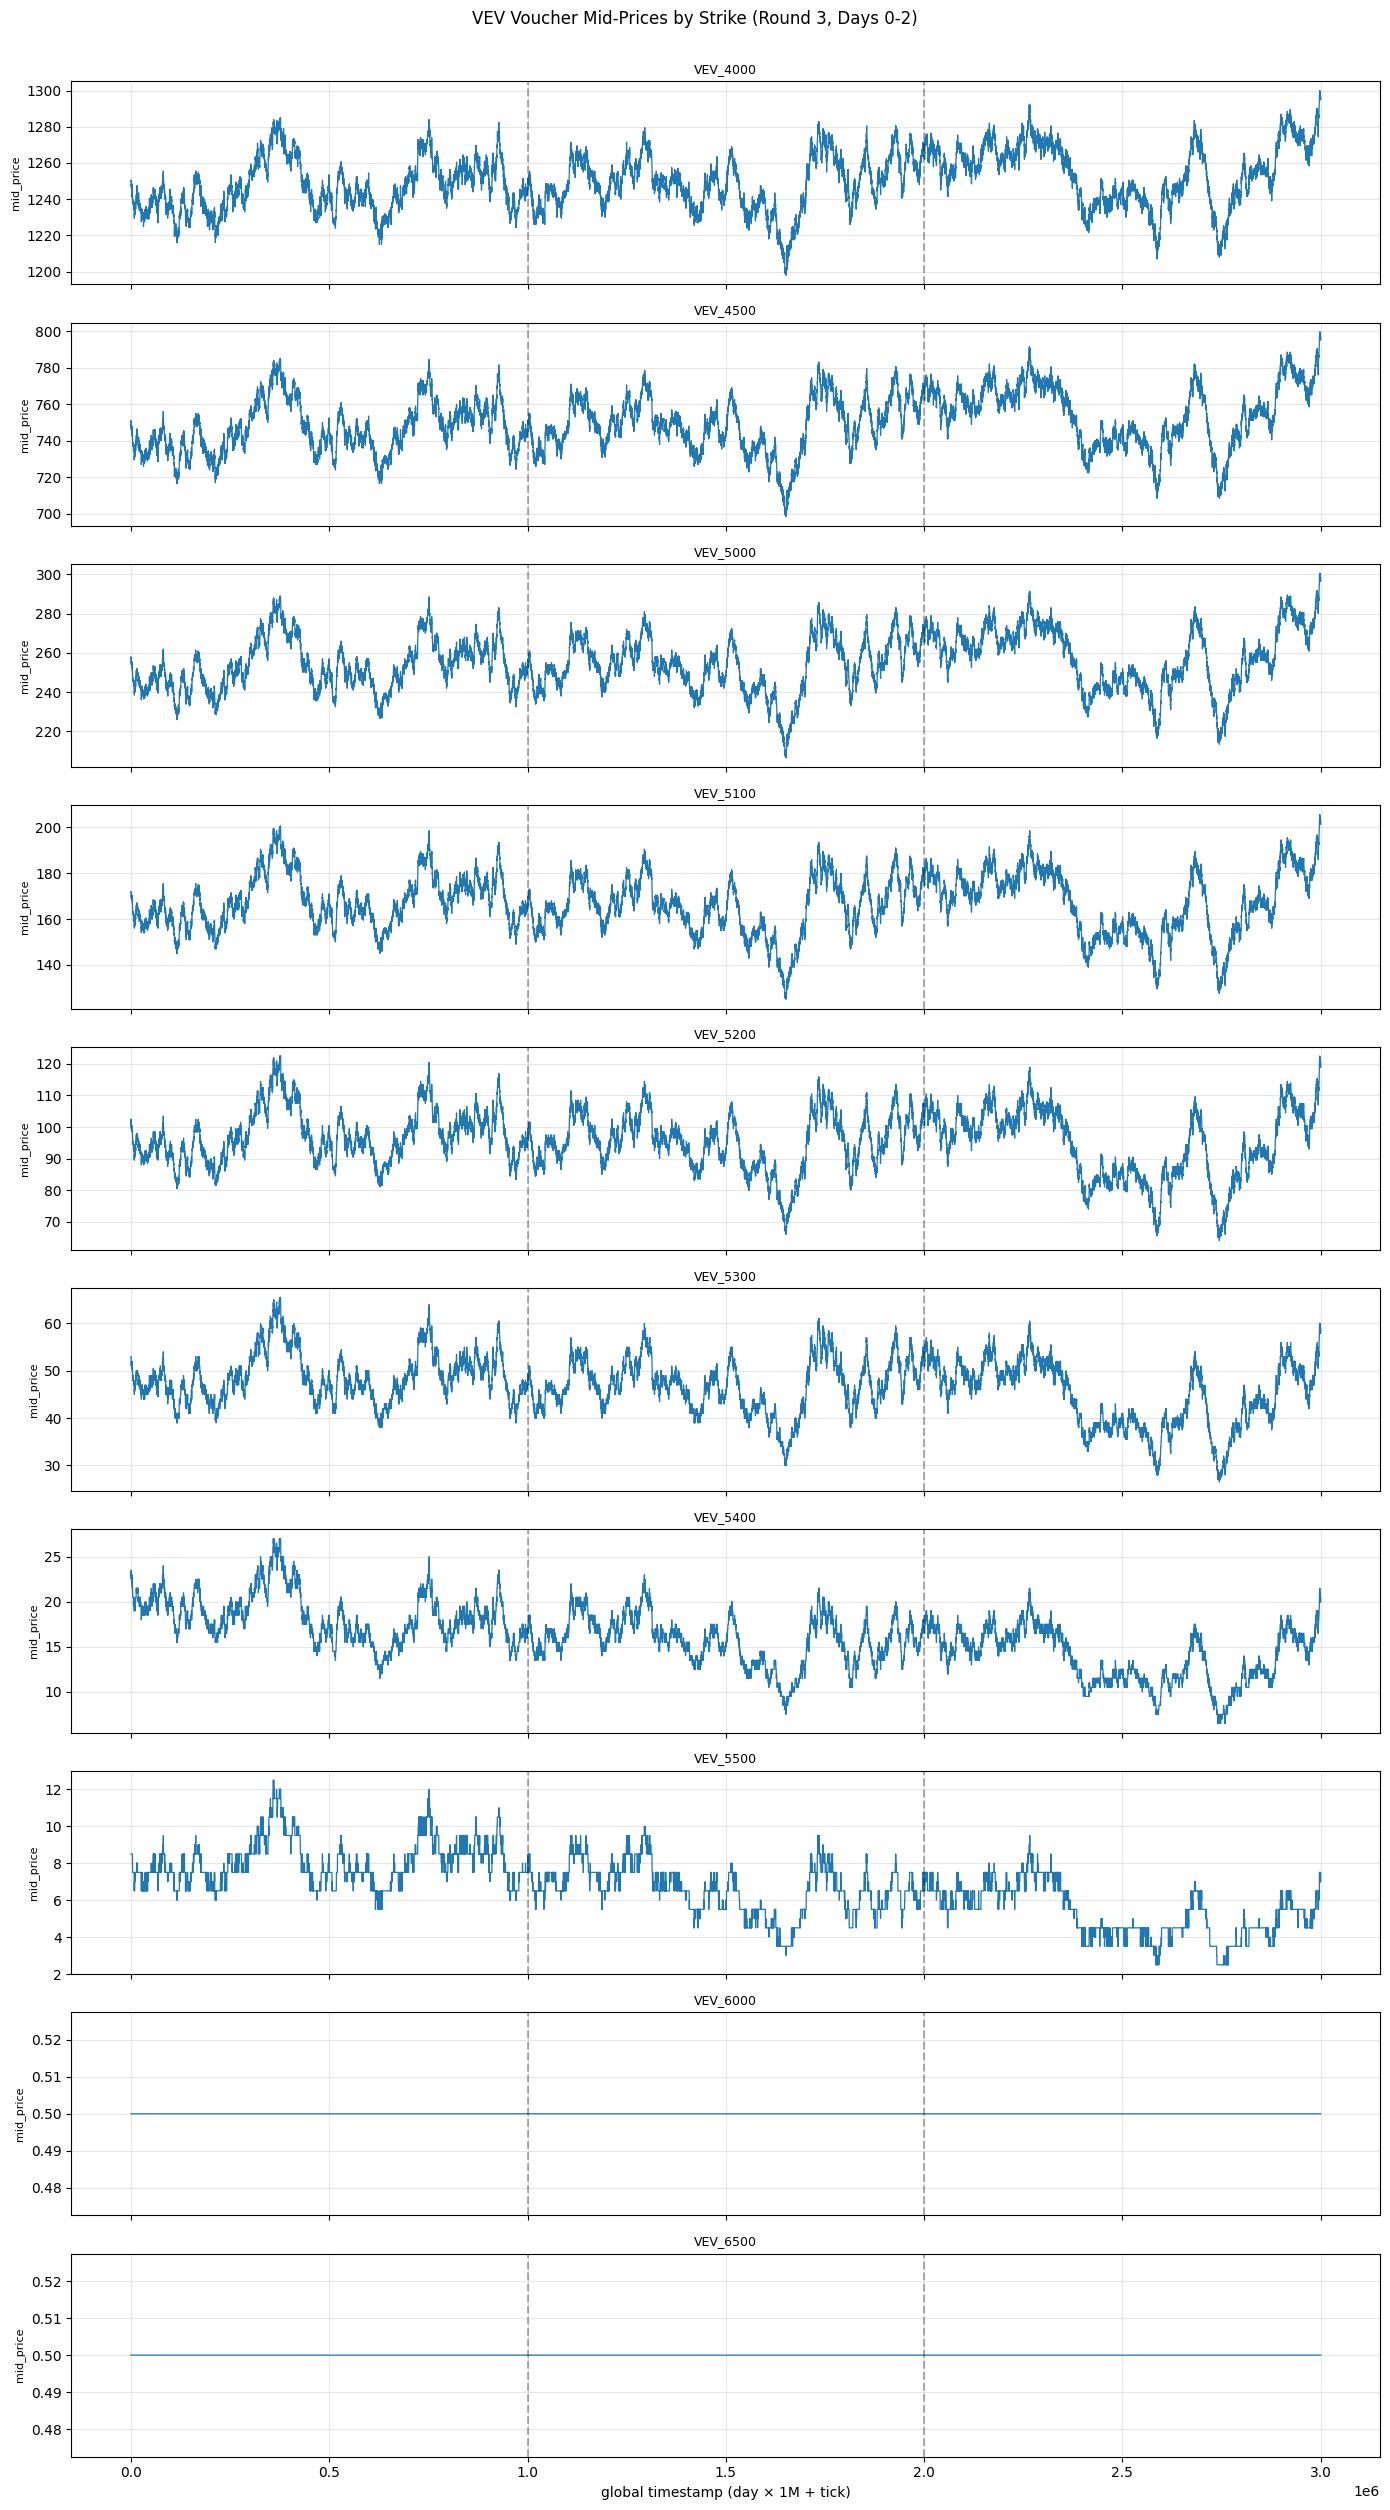

In [560]:
# Mid-price for each VEV voucher strike across all 3 days
r3_vouchers = r3_prices[r3_prices["product"].str.startswith("VEV")].copy()
r3_vouchers["global_ts"] = r3_vouchers["day"] * 1_000_000 + r3_vouchers["timestamp"]
r3_vouchers = r3_vouchers.sort_values("global_ts")

strikes = sorted(r3_vouchers["product"].unique(), key=lambda x: int(x.split("_")[1]))

fig, axes = plt.subplots(len(strikes), 1, figsize=(14, 2.5 * len(strikes)), sharex=True)

for ax, strike in zip(axes, strikes):
    df = r3_vouchers[r3_vouchers["product"] == strike]
    ax.plot(df["global_ts"], df["mid_price"], linewidth=0.9)
    ax.set_ylabel("mid_price", fontsize=8)
    ax.set_title(strike, fontsize=9)
    ax.grid(True, alpha=0.3)
    # day separators
    for day in [1, 2]:
        ax.axvline(x=day * 1_000_000, color="black", linestyle="--", alpha=0.3)

axes[-1].set_xlabel("global timestamp (day × 1M + tick)")
plt.suptitle("VEV Voucher Mid-Prices by Strike (Round 3, Days 0-2)", fontsize=12, y=1.002)
plt.tight_layout()
plt.show()


# Round 3 Analysis: HYDROGEL_PACK & VELVETFRUIT_EXTRACT

In [561]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load all 3 days of round 3 prices, filter out vouchers
r3_price_paths = [
    "../datasets/round3/prices_round_3_day_0.csv",
    "../datasets/round3/prices_round_3_day_1.csv",
    "../datasets/round3/prices_round_3_day_2.csv",
]
r3_prices = pd.concat([pd.read_csv(p, sep=";") for p in r3_price_paths], ignore_index=True)
r3_commodities = r3_prices[~r3_prices["product"].str.startswith("VEV")]

products_r3 = r3_commodities["product"].unique()
print("Round 3 commodities:", products_r3)
print(r3_commodities.groupby(["product", "day"]).size())


Round 3 commodities: <StringArray>
['VELVETFRUIT_EXTRACT', 'HYDROGEL_PACK']
Length: 2, dtype: str
product              day
HYDROGEL_PACK        0      10000
                     1      10000
                     2      10000
VELVETFRUIT_EXTRACT  0      10000
                     1      10000
                     2      10000
dtype: int64


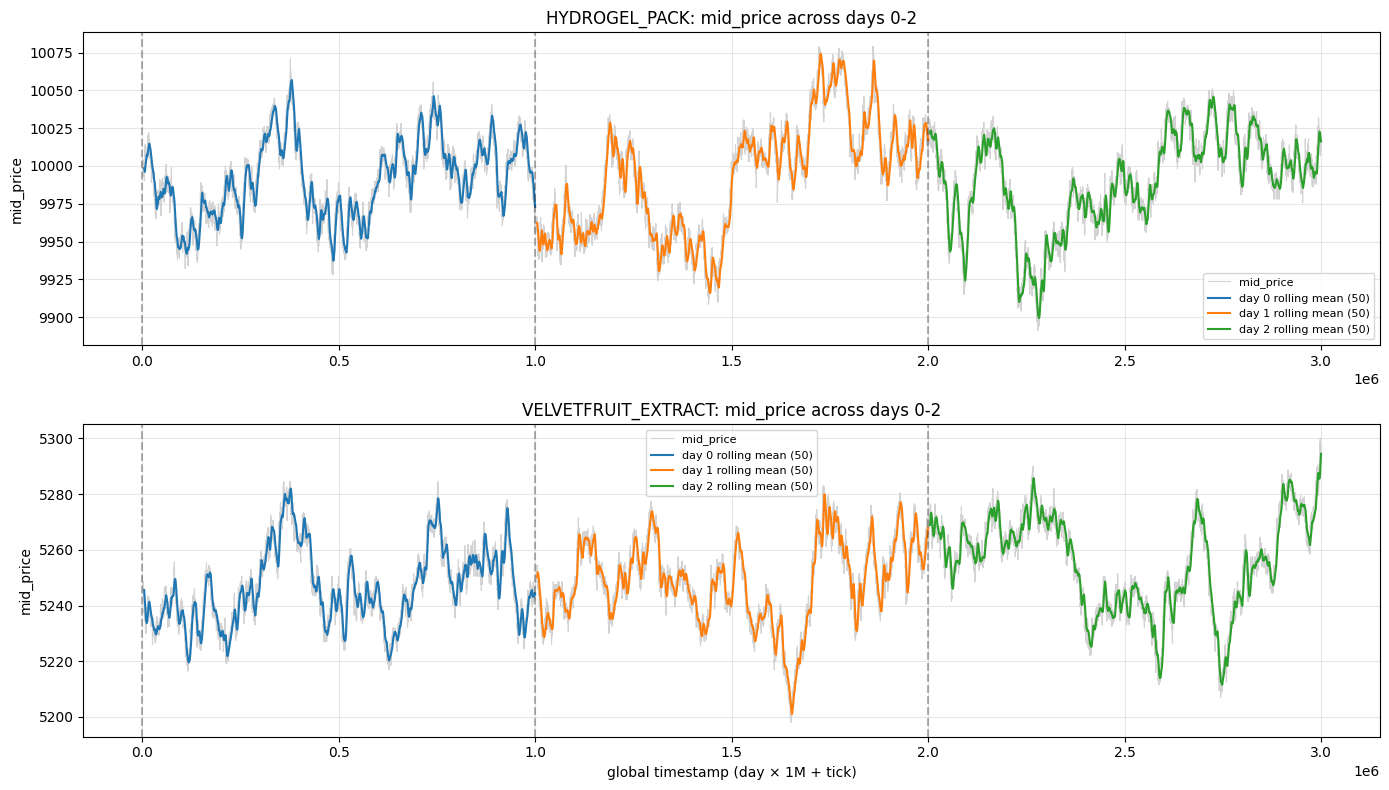

In [562]:
# Mid-price per day for each commodity, with 50-tick rolling mean
window = 50
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

colors = ['steelblue', 'darkorange', 'green']

for ax, product in zip(axes, ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]):
    df = r3_commodities[r3_commodities["product"] == product].copy()
    df["global_ts"] = df["day"] * 1_000_000 + df["timestamp"]
    df = df.sort_values("global_ts")

    ax.plot(df["global_ts"], df["mid_price"], color="lightgray", linewidth=0.8, label="mid_price")

    # Day boundaries
    for day, grp in df.groupby("day"):
        roll = grp["mid_price"].rolling(window=window, min_periods=window).mean()
        ax.plot(grp["global_ts"], roll, label=f"day {day} rolling mean ({window})")
        # vertical day separator
        ax.axvline(x=grp["global_ts"].iloc[0], color="black", linestyle="--", alpha=0.3)

    ax.set_title(f"{product}: mid_price across days 0-2")
    ax.set_ylabel("mid_price")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("global timestamp (day × 1M + tick)")
plt.tight_layout()
plt.show()


In [563]:
# Daily average mid_price and overall stats for round 3 commodities
for product in ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]:
    df = r3_commodities[r3_commodities["product"] == product]
    daily_avg = df.groupby("day")["mid_price"].agg(["mean", "std", "min", "max"])
    print(f"\n=== {product} ===")
    print(daily_avg.round(2))
    print(f"Overall mean: {df['mid_price'].mean():.2f}, std: {df['mid_price'].std():.2f}")



=== HYDROGEL_PACK ===
        mean    std     min      max
day                                 
0    9990.96  25.33  9928.0  10071.0
1    9992.06  37.61  9908.5  10079.0
2    9989.40  31.62  9891.0  10051.0
Overall mean: 9990.81, std: 31.94

=== VELVETFRUIT_EXTRACT ===
        mean    std     min     max
day                                
0    5246.51  13.68  5216.5  5284.5
1    5248.39  14.61  5198.0  5283.0
2    5255.39  16.99  5207.0  5300.0
Overall mean: 5250.10, std: 15.63
